# Identificação NARX Polinomial e MPC Aproximado — Ball and Beam

**Sistema:** Ball and Beam / Motor DC  
**Programa:** PPGEPS — PUCPR  
**Escopo:** Simulação sobre modelo NARX identificado  
*(Validação na planta física constitui etapa futura de pesquisa)*

---

## Resumo do pipeline

```
Dados experimentais (.mat)
        ↓
  Decimação (FIR, zero-phase)
        ↓
  Identificação NARX Polinomial
  ┌─ FROLS  →  seleção de estrutura
  ├─ Ridge  →  estimação OSA
  └─ SEM    →  refinamento free-run
        ↓
  NMPC Professor  (CasADi / IPOPT)
        ↓
  MPC Aproximado  (MLP — imitação da política NMPC)
        ↓
  Comparação NMPC × MPC Aproximado
```

---

## Fundamentação matemática

### Modelo NARX Polinomial

O modelo NARX (*Nonlinear AutoRegressive with eXogenous inputs*) expressa a saída atual como função dos atrasos passados da saída e da entrada:

$$\hat{y}(k) = f\bigl(y(k-1),\dots,y(k-n_y),\; u(k-1),\dots,u(k-n_u)\bigr)$$

Na versão polinomial, $f$ é um polinômio de grau $d$ nos regressores:

$$\hat{y}(k) = \sum_{i=1}^{n_t} \theta_i \, \phi_i\bigl(\mathbf{x}(k)\bigr), \quad \mathbf{x}(k) = [y(k-1),\dots,u(k-n_u)]^\top$$

onde $\phi_i$ são monômios selecionados pelo FROLS.

### Seleção de termos — FROLS

O algoritmo FROLS (*Forward Regression via Orthogonal Least Squares*) seleciona iterativamente os $n_t$ termos que maximizam a redução de erro ortogonal (ERR):

$$\text{ERR}_i = \frac{\langle \mathbf{q}_i, \mathbf{y} \rangle^2}{\|\mathbf{q}_i\|^2 \, \|\mathbf{y}\|^2}$$

onde $\mathbf{q}_i$ é a projeção ortogonalizada da coluna $i$ da biblioteca polinomial.

### Estimação — Ridge

Os coeficientes $\boldsymbol{\theta}$ são estimados minimizando o erro OSA com regularização L2:

$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \left\{ \|\mathbf{\Phi}\boldsymbol{\theta} - \mathbf{y}\|^2 + \alpha \|\boldsymbol{\theta}\|^2 \right\}$$

### Refinamento — SEM (Simulation Error Minimization)

Após o Ridge, os coeficientes são refinados minimizando o erro de simulação livre (*free-run*), que é o critério para uso recursivo no MPC:

$$\hat{\boldsymbol{\theta}}_{\text{SEM}} = \arg\min_{\boldsymbol{\theta}} \left\{ \text{RMSE}_{\text{FR}}(\boldsymbol{\theta}) + \lambda \|\boldsymbol{\theta} - \hat{\boldsymbol{\theta}}_{\text{Ridge}}\|^2 \right\}$$

Otimização via L-BFGS-B. O parâmetro $\lambda$ (`lambda_sem`) controla o quão longe os coeficientes podem se afastar da solução Ridge.

### NMPC Professor

Em cada instante $k$, resolve o problema de otimização de horizonte finito:

$$\min_{\mathbf{u}} \sum_{j=0}^{N-1} \left[ Q\,e_j^2 + R\,u_j^2 + R_d\,(\Delta u_j)^2 \right] + Q_N\,e_N^2$$

sujeito a:
$$x_{j+1} = f_{\text{NARX}}(x_j, u_j), \quad u_{\min} \le u_j \le u_{\max}, \quad |\Delta u_j| \le \Delta u_{\max}, \quad y_{\min} \le y_j \le y_{\max}$$

onde $e_j = y_j - r$ é o erro de rastreamento. Resolvido com IPOPT via CasADi.

### MPC Aproximado

Uma rede MLP aprende a política ótima do NMPC por imitação:

$$u^*(k) \approx \pi_\theta\bigl([x(k),\; r(k)]\bigr)$$

Eliminando a necessidade de resolver a otimização online, permitindo execução em tempo real embarcado.


## Seção 0 — Ambiente e Configuração

In [ ]:
# =============================================================================
# CÉLULA 0A — INSTALAÇÃO DE DEPENDÊNCIAS
# Execute apenas na primeira vez ou quando o ambiente for reiniciado.
# =============================================================================

!pip install casadi tqdm scipy -q
print('Dependências instaladas.')


Dependências instaladas.


In [ ]:
# =============================================================================
# CÉLULA 0B — IMPORTS E MONTAGEM DO GOOGLE DRIVE
# =============================================================================

import os, warnings, pickle, json, shutil, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# import bab_datasets as nod

from pathlib import Path
from scipy.io import loadmat
from scipy.signal import decimate
from scipy.optimize import minimize
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

try:
    import casadi as ca
    CASADI_OK = True
    print('✓ CasADi carregado.')
except Exception as e:
    CASADI_OK = False
    print(f'✗ CasADi não disponível: {e}')

# Monta o Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('Imports OK.')


✓ CasADi carregado.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imports OK.


In [ ]:
# =============================================================================
# CÉLULA 0C — CONFIGURAÇÕES GERAIS
# Todos os hiperparâmetros do pipeline estão centralizados aqui.
# Ajuste PATH_DATA para o caminho da sua pasta no Drive.
# =============================================================================

# ── Caminhos ─────────────────────────────────────────────────────────────────
PATH_DATA  = '/content/drive/MyDrive/bab_dados_mat/'
PATH_SAVE  = '/content/drive/MyDrive/bab_dados_mat/'

# ── Amostragem ───────────────────────────────────────────────────────────────
# Decimação de 10× reduz de 1 kHz para 100 Hz (Ts = 10 ms).
# Aumentar DECIM para 20 reduz ruído mas pode perder dinâmica rápida.
config = {
    'output_key_preferida': 'yf',   # usa sinal filtrado se disponível
    'Ts_original': 0.001,           # período de amostragem original (s)
    'DECIM': 10,                    # fator de decimação

    # ── Estrutura NARX inicial ────────────────────────────────────────────────
    # ny: número de atrasos da saída  |  nu: número de atrasos da entrada
    # degree: grau máximo dos monômios polinomiais
    # n_terms: número de termos selecionados pelo FROLS
    'ny': 2, 'nu': 3, 'degree': 3, 'n_terms': 8,
    'include_bias': True,

    # ── Ridge — regularização OSA ─────────────────────────────────────────────
    # alpha=0 → mínimos quadrados puro; aumente se coeficientes explodirem
    'ridge_alpha': 1e-4,

    # ── SEM — Simulation Error Minimization ──────────────────────────────────
    # lambda_sem: regularização L2 em torno da solução Ridge
    # sem_maxiter: máximo de iterações do L-BFGS-B
    'use_sem': True,
    'lambda_sem': 1e-4,
    'sem_maxiter': 800,

    # ── Conjuntos de dados ────────────────────────────────────────────────────
    # Treino: 4 arquivos com tipos de excitação distintos
    # Validação: swept_sine (melhor cobertura espectral) + random_steps extra
    # Teste: reservado para avaliação final — não use durante o desenvolvimento
    'files_train': [
        '03_random_steps_02.mat',
        '03_random_steps_03.mat',
        '06_multisine_02.mat',
        '05_multisine_01.mat',
    ],
    'files_val':  ['04_swept_sine.mat', '03_random_steps_04.mat'],
    'files_test': ['03_random_steps_04.mat'],

    # ── Limites físicos ───────────────────────────────────────────────────────
    'remove_mean': False,
    'u_min': -10.0, 'u_max': 10.0,
    'y_min':  -5.0, 'y_max':  5.0,
}

Ts = config['Ts_original'] * config['DECIM']
print(f'Período de amostragem após decimação: Ts = {Ts:.4f} s  (fs = {1/Ts:.1f} Hz)')
print(f'Treino  ({len(config["files_train"])} arquivos):', config['files_train'])
print(f'Validação ({len(config["files_val"])} arquivos):', config['files_val'])
print(f'Teste   ({len(config["files_test"])} arquivo) :', config['files_test'])


Período de amostragem após decimação: Ts = 0.0100 s  (fs = 100.0 Hz)
Treino  (4 arquivos): ['03_random_steps_02.mat', '03_random_steps_03.mat', '06_multisine_02.mat', '05_multisine_01.mat']
Validação (2 arquivos): ['04_swept_sine.mat', '03_random_steps_04.mat']
Teste   (1 arquivo) : ['03_random_steps_04.mat']


## Seção 1 — Carregamento e Pré-processamento dos Dados

Inspecionando arquivos de treino:


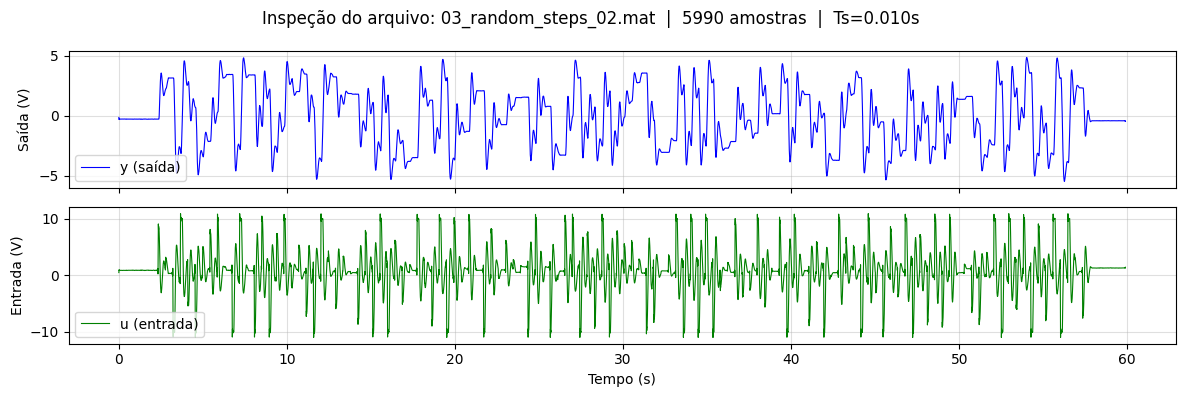

  u: [-11.04, 10.92] V  |  y: [-5.48, 4.85] V  |  duração: 59.9 s


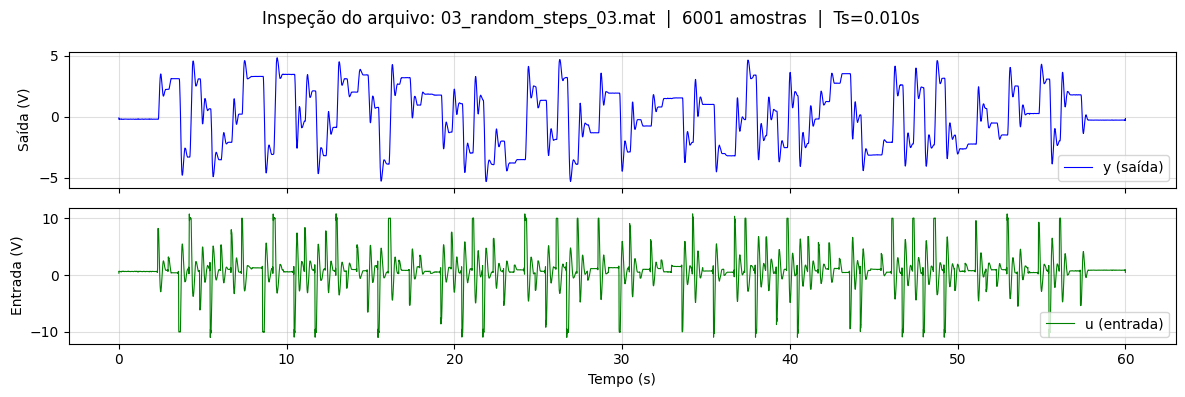

  u: [-11.01, 10.82] V  |  y: [-5.33, 4.83] V  |  duração: 60.0 s


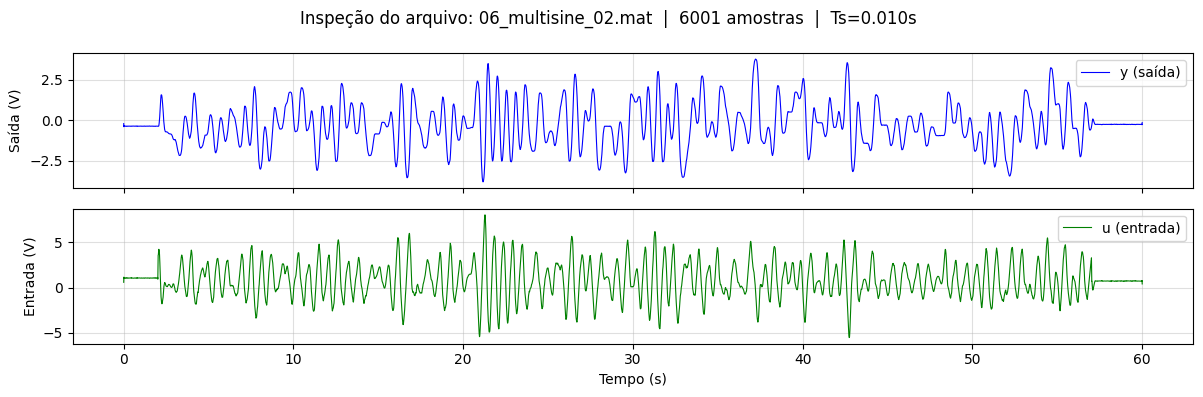

  u: [-5.55, 8.07] V  |  y: [-3.79, 3.79] V  |  duração: 60.0 s


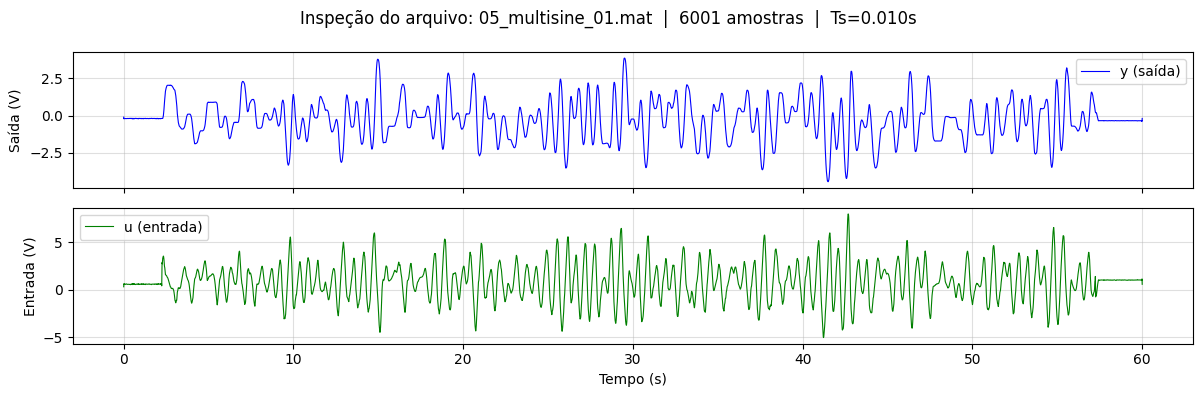

  u: [-5.02, 8.00] V  |  y: [-4.42, 3.84] V  |  duração: 60.0 s


In [ ]:
# =============================================================================
# CÉLULA 1A — FUNÇÕES DE CARREGAMENTO
# =============================================================================
# Os arquivos .mat contêm os sinais brutos amostrados a 1 kHz.
# Pré-processamento aplicado:
#   1. Leitura de 'yf' (filtrado) ou 'y' se 'yf' não existir
#   2. Remoção de amostras inválidas (NaN / Inf)
#   3. Decimação com filtro FIR zero-phase (evita distorção de fase)
#   4. Remoção da média (centraliza em torno do ponto de operação)
# =============================================================================

def load_bab_mat(filename, path_data=PATH_DATA,
                 output_key_preferida='yf', remove_mean=True, decim=10):
    full_path = os.path.join(path_data, filename)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f'Arquivo não encontrado: {full_path}')
    data  = loadmat(full_path)
    y_key = output_key_preferida if output_key_preferida in data else 'y'
    u = np.asarray(data['u']).squeeze().astype(float)
    y = np.asarray(data[y_key]).squeeze().astype(float)
    n = min(len(u), len(y)); u, y = u[:n], y[:n]
    mask = np.isfinite(u) & np.isfinite(y); u, y = u[mask], y[mask]
    if decim and decim > 1:
        u = decimate(u, decim, ftype='fir', zero_phase=True)
        y = decimate(y, decim, ftype='fir', zero_phase=True)
    if remove_mean:
        u -= np.mean(u); y -= np.mean(y)
    return u, y


def quick_plot_file(filename):
    """Inspeciona visualmente um arquivo do dataset antes do treino."""
    u, y = load_bab_mat(filename, output_key_preferida=config['output_key_preferida'],
                        remove_mean=config['remove_mean'], decim=config['DECIM'])
    t = np.arange(len(y)) * Ts
    fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
    ax[0].plot(t, y, 'b', lw=0.8, label='y (saída)'); ax[0].set_ylabel('Saída (V)')
    ax[0].grid(True, alpha=0.4); ax[0].legend()
    ax[1].plot(t, u, 'g', lw=0.8, label='u (entrada)'); ax[1].set_ylabel('Entrada (V)')
    ax[1].set_xlabel('Tempo (s)'); ax[1].grid(True, alpha=0.4); ax[1].legend()
    fig.suptitle(f'Inspeção do arquivo: {filename}  |  {len(y)} amostras  |  Ts={Ts:.3f}s')
    plt.tight_layout(); plt.show()
    print(f'  u: [{u.min():.2f}, {u.max():.2f}] V  |  '
          f'y: [{y.min():.2f}, {y.max():.2f}] V  |  '
          f'duração: {len(y)*Ts:.1f} s')


print('Inspecionando arquivos de treino:')
for fname in config['files_train']:
    quick_plot_file(fname)


## Seção 2 — Identificação NARX Polinomial

In [ ]:
# =============================================================================
# CÉLULA 2A — NÚCLEO NARX: FROLS + RIDGE + SEM
# =============================================================================
# Três estágios de identificação:
#
# Estágio 1 — FROLS
#   Seleciona os n_terms monômios mais relevantes da biblioteca polinomial.
#   Critério: maior redução de erro ortogonal (ERR) a cada iteração.
#
# Estágio 2 — Ridge
#   Estima theta minimizando: ||Φθ - y||² + α||θ||²
#   A regularização L2 evita coeficientes muito grandes quando os regressores
#   são correlacionados (problema comum em bibliotecas polinomiais).
#
# Estágio 3 — SEM (Simulation Error Minimization)
#   Refina theta minimizando o RMSE do free-run diretamente.
#   Necessário porque o Ridge minimiza o erro OSA (um passo), mas o modelo
#   será usado de forma recursiva no MPC — o critério correto é o free-run.
#   Otimizador: L-BFGS-B com regularização L2 em torno da solução Ridge.
# =============================================================================

def build_lag_matrix(u, y, ny, nu):
    """
    Constrói a matriz de regressores NARX.
    Retorna X_base de shape (N, ny+nu), target y(k) e nomes das variáveis.
    """
    u, y = np.asarray(u).squeeze(), np.asarray(y).squeeze()
    ml   = max(ny, nu)
    N    = len(y) - ml
    y_cols = np.stack([y[ml-i : ml-i+N] for i in range(1, ny+1)], axis=1)
    u_cols = np.stack([u[ml-j : ml-j+N] for j in range(1, nu+1)], axis=1)
    var_names = ([f'y(k-{i})' for i in range(1, ny+1)] +
                 [f'u(k-{j})' for j in range(1, nu+1)])
    return np.hstack([y_cols, u_cols]), y[ml:], var_names


def build_poly_library(X_base, var_names, degree=2, include_bias=True):
    """Expande X_base para uma biblioteca polinomial de grau d."""
    poly = PolynomialFeatures(degree=degree, include_bias=include_bias)
    Phi  = poly.fit_transform(X_base)
    return Phi, list(poly.get_feature_names_out(var_names)), poly.powers_.copy(), poly


def frols_select_terms(Phi, y, n_terms=8, eps=1e-12):
    """Seleciona n_terms termos por FROLS (maximiza ERR ortogonal)."""
    Phi = np.asarray(Phi, dtype=float)
    y   = np.asarray(y,   dtype=float).reshape(-1)
    nrm = np.linalg.norm(Phi, axis=0); nrm[nrm < eps] = 1.0
    Z   = Phi / nrm
    selected, Q = [], []
    y_e = float(np.dot(y, y)) + eps
    for _ in range(min(n_terms, Z.shape[1])):
        best_i, best_e, best_q = None, -np.inf, None
        for idx in range(Z.shape[1]):
            if idx in selected: continue
            q = Z[:, idx].copy()
            for qp in Q: q -= (np.dot(qp, q) / (np.dot(qp, qp) + eps)) * qp
            qe = np.dot(q, q)
            if qe < eps: continue
            e = (np.dot(q, y)**2) / (qe * y_e)
            if e > best_e: best_e, best_i, best_q = e, idx, q
        if best_i is None: break
        selected.append(best_i); Q.append(best_q)
    return selected


def predict_from_base_numpy(base, model):
    """
    Avalia o modelo NARX polinomial de forma vetorizada.
    Usa broadcasting: (N,1,V)^powers → (N,T) @ theta → (N,)
    Aceita base de shape (n_vars,) ou (N, n_vars).
    """
    base = np.asarray(base, dtype=float)
    single = (base.ndim == 1)
    if single: base = base[np.newaxis, :]
    powers = model['selected_powers']
    terms  = np.prod(base[:, np.newaxis, :] ** powers[np.newaxis, :, :], axis=2)
    result = terms @ model['theta']
    return float(result[0]) if single else result


def _pack_model(model, theta):
    m = {k: v for k, v in model.items()}
    m['theta'] = np.asarray(theta, dtype=float)
    return m


def simulate_free_run(u, y, model):
    """
    Simulação livre (free-run): retroalimenta ŷ como regressor.
    Equivalente ao uso do modelo dentro do NMPC.
    """
    ny, nu = model['ny'], model['nu']
    ml     = max(ny, nu)
    y_sim  = np.zeros_like(y, dtype=float)
    y_sim[:ml] = y[:ml]
    for k in range(ml, len(y)):
        base = ([y_sim[k-i] for i in range(1, ny+1)] +
                [u[k-j]     for j in range(1, nu+1)])
        y_sim[k] = predict_from_base_numpy(np.array(base), model)
        if not np.isfinite(y_sim[k]): y_sim[k] = y_sim[k-1]
        y_sim[k] = np.clip(y_sim[k], -20., 20.)
    return y_sim


def refine_theta_sem(model, file_list, cfg):
    """SEM: refina theta minimizando RMSE do free-run via L-BFGS-B."""
    u_list, y_list = [], []
    for fname in file_list:
        u, y = load_bab_mat(fname, output_key_preferida=cfg['output_key_preferida'],
                            remove_mean=cfg['remove_mean'], decim=cfg['DECIM'])
        u_list.append(u); y_list.append(y)

    def fr_rmse(theta):
        m = _pack_model(model, theta)
        errs = []
        for u, y in zip(u_list, y_list):
            ys = simulate_free_run(u, y, m)
            ml = max(m['ny'], m['nu'])
            errs.append(np.mean((y[ml:] - ys[ml:])**2))
        return float(np.mean(errs))

    lam, mit = cfg.get('lambda_sem', 1e-3), cfg.get('sem_maxiter', 500)
    theta0   = model['theta'].copy()

    def objective(theta):
        return fr_rmse(theta) + lam * np.sum((theta - theta0)**2)

    rmse_ini = fr_rmse(theta0)
    print(f'  SEM: RMSE free-run inicial = {rmse_ini:.6f}')

    iters = [0]
    with tqdm(total=mit, desc='  SEM L-BFGS-B', leave=False) as pbar:
        def cb(theta):
            iters[0] += 1; pbar.update(1)
            pbar.set_postfix(rmse=f'{fr_rmse(theta):.5f}')
        result = minimize(objective, theta0, method='L-BFGS-B', callback=cb,
                          options={'maxiter': mit, 'ftol': 1e-12, 'gtol': 1e-8})

    rmse_fin = fr_rmse(result.x)
    print(f'  SEM: RMSE free-run final   = {rmse_fin:.6f}')
    print(f'  SEM: convergiu={result.success}  msg="{result.message}"')
    print(f'  SEM: redução RMSE = {100*(rmse_ini-rmse_fin)/rmse_ini:.1f}%')
    return _pack_model(model, result.x)


def fit_narx_polynomial(file_list, cfg, verbose=True):
    """Pipeline completo: FROLS → Ridge → SEM (se use_sem=True)."""
    X_list, y_list, var_names = [], [], None
    for fname in file_list:
        u, y = load_bab_mat(fname, output_key_preferida=cfg['output_key_preferida'],
                            remove_mean=cfg['remove_mean'], decim=cfg['DECIM'])
        Xb, yt, names = build_lag_matrix(u, y, cfg['ny'], cfg['nu'])
        X_list.append(Xb); y_list.append(yt); var_names = names
    X_base = np.vstack(X_list)
    y_train = np.concatenate(y_list)
    Phi, feature_names, powers, _ = build_poly_library(
        X_base, var_names, cfg['degree'], cfg['include_bias'])
    sel_idx = frols_select_terms(Phi, y_train, n_terms=cfg['n_terms'])
    ridge   = Ridge(alpha=cfg.get('ridge_alpha', 1e-4), fit_intercept=False)
    ridge.fit(Phi[:, sel_idx], y_train)
    model = {
        'theta': ridge.coef_, 'selected_idx': sel_idx,
        'selected_names': [feature_names[i] for i in sel_idx],
        'selected_powers': powers[sel_idx], 'feature_names_all': feature_names,
        'powers_all': powers, 'var_names': var_names,
        'ny': cfg['ny'], 'nu': cfg['nu'],
        'degree': cfg['degree'], 'include_bias': cfg['include_bias'],
    }
    if cfg.get('use_sem', False):
        if verbose: print('  Iniciando SEM...')
        model = refine_theta_sem(model, file_list, cfg)
    return model, X_base, y_train


def check_stability(model):
    """Verifica se o polo dominante está dentro do círculo unitário."""
    lin_y = [c for n, c in zip(model['selected_names'], model['theta'])
             if n.startswith('y(k-') and n.count('(') == 1]
    if lin_y:
        soma = sum(lin_y); soma_abs = sum(abs(c) for c in lin_y)
        print(f'  Coef. lineares y: {[f"{c:+.4f}" for c in lin_y]}')
        print(f'  Soma = {soma:+.4f}  |  Σ|coef| = {soma_abs:.4f}')
        if soma_abs > 0.95:
            print('  ⚠ Polo dominante próximo do círculo unitário — free-run pode ser instável.')
        else:
            print('  ✓ Coeficientes dentro do limite de estabilidade.')


def dominant_pole_penalty(model, threshold=0.98):
    lin_y = [c for n, c in zip(model['selected_names'], model['theta'])
             if n.startswith('y(k-') and n.count('(') == 1]
    return max(0., sum(abs(c) for c in lin_y) - threshold) * 100. if lin_y else 0.


def print_model_terms(model):
    print('\nModelo NARX polinomial — termos selecionados:')
    for name, coef in zip(model['selected_names'], model['theta']):
        print(f'  {coef:+.8e}  ×  {name}')
    print(f'  ({len(model["theta"])} termos  |  ny={model["ny"]}  nu={model["nu"]}  grau={model["degree"]})')
    check_stability(model)


print('Funções NARX definidas.')


Funções NARX definidas.


In [ ]:
# =============================================================================
# CÉLULA 2B — FUNÇÕES DE AVALIAÇÃO OSA E FREE-RUN
# =============================================================================
# Dois critérios de avaliação do modelo NARX:
#
# OSA (One-Step Ahead):
#   Prediz y(k) usando os valores REAIS de y(k-1),...,u(k-1),...
#   Métrica: RMSE_OSA, R²_OSA, FIT_OSA%
#   Uso: diagnóstico da estrutura do modelo.
#
# Free-Run (simulação livre / parallel simulation):
#   Prediz y(k) usando a própria saída SIMULADA nos atrasos.
#   Equivalente exato ao uso dentro do NMPC.
#   Métrica: RMSE_FR, R²_FR, FIT_FR%
#   Uso: critério de avanço para o NMPC (FIT_FR% ≥ 65%).
#
# FIT% (índice de ajuste NRMSE):
#   FIT% = 100 × (1 - ||y - ŷ|| / ||y - ȳ||)
#   FIT% = 100%: predição perfeita
#   FIT% = 0%  : equivalente a predizer a média
#   FIT% < 0%  : pior que predizer a média (modelo instável no free-run)
# =============================================================================

def evaluate_osa(file_list, model, cfg, title='', verbose=True):
    if verbose: print(f'\n--- {title} | One-Step Ahead ---')
    rows = []
    for fname in file_list:
        u, y = load_bab_mat(fname, output_key_preferida=cfg['output_key_preferida'],
                            remove_mean=cfg['remove_mean'], decim=cfg['DECIM'])
        Xb, yt, _ = build_lag_matrix(u, y, model['ny'], model['nu'])
        Phi, _, _, _ = build_poly_library(Xb, model['var_names'],
                                           model['degree'], model['include_bias'])
        yhat = Phi[:, model['selected_idx']] @ model['theta']
        rmse = np.sqrt(mean_squared_error(yt, yhat))
        r2   = r2_score(yt, yhat)
        fit  = 100*(1 - np.linalg.norm(yt-yhat) / (np.linalg.norm(yt-np.mean(yt))+1e-12))
        rows.append({'arquivo': fname, 'RMSE_OSA': rmse, 'R2_OSA': r2, 'FIT_OSA_%': fit})
        if verbose: print(f'  {fname:32s}  RMSE:{rmse:.5f}  R²:{r2:.5f}  FIT:{fit:.2f}%')
    return pd.DataFrame(rows)


def evaluate_free_run(file_list, model, cfg, title='', plot=True, verbose=True):
    if verbose: print(f'\n--- {title} | Free-Run ---')
    rows = []
    for fname in file_list:
        u, y  = load_bab_mat(fname, output_key_preferida=cfg['output_key_preferida'],
                             remove_mean=cfg['remove_mean'], decim=cfg['DECIM'])
        y_sim = simulate_free_run(u, y, model)
        ml    = max(model['ny'], model['nu'])
        yt, yh = y[ml:], y_sim[ml:]
        rmse  = np.sqrt(mean_squared_error(yt, yh))
        r2    = r2_score(yt, yh)
        fit   = 100*(1 - np.linalg.norm(yt-yh) / (np.linalg.norm(yt-np.mean(yt))+1e-12))
        rows.append({'arquivo': fname, 'RMSE_FR': rmse, 'R2_FR': r2, 'FIT_FR_%': fit})
        if verbose: print(f'  {fname:32s}  RMSE:{rmse:.5f}  R²:{r2:.5f}  FIT:{fit:.2f}%')
        if plot:
            t = np.arange(len(y)) * Ts
            fig, ax = plt.subplots(figsize=(12, 3))
            ax.plot(t, y, 'b', lw=0.8, label='Medido')
            ax.plot(t, y_sim, 'r--', lw=0.8, label='Free-run simulado')
            ax.set_title(f'Free-Run — {fname}  |  FIT={fit:.1f}%  R²={r2:.4f}')
            ax.set_xlabel('Tempo (s)'); ax.set_ylabel('Saída (V)')
            ax.grid(True, alpha=0.4); ax.legend(); plt.tight_layout(); plt.show()
    return pd.DataFrame(rows)


def plot_residual_diagnostics(file_list, model, cfg, n_lags=40, title=''):
    """
    Diagnóstico de resíduos OSA:
      - ACF: deve cair rapidamente (resíduos próximos de ruído branco)
      - xcorr resíduo × entrada: deve ser próxima de zero
        (caso contrário, dinâmica de entrada não capturada)
    Bandas de 95%: ±1.96/√N
    """
    for fname in file_list:
        u, y = load_bab_mat(fname, output_key_preferida=cfg['output_key_preferida'],
                            remove_mean=cfg['remove_mean'], decim=cfg['DECIM'])
        Xb, yt, _ = build_lag_matrix(u, y, model['ny'], model['nu'])
        Phi, _, _, _ = build_poly_library(Xb, model['var_names'],
                                           model['degree'], model['include_bias'])
        res  = yt - Phi[:, model['selected_idx']] @ model['theta']
        u_al = u[max(model['ny'], model['nu']):]
        nm   = min(len(res), len(u_al))
        res, u_al = res[:nm], u_al[:nm]
        conf = 1.96 / np.sqrt(len(res))
        acf = np.array([1.0 if lag==0 else np.corrcoef(res[:-lag], res[lag:])[0,1]
                        for lag in range(n_lags+1)])
        xcr = np.array([np.corrcoef(res, u_al)[0,1] if lag==0
                        else np.corrcoef(res[:-lag], u_al[lag:])[0,1]
                        for lag in range(n_lags+1)])
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f'Diagnóstico de resíduos OSA — {title} — {fname}', fontsize=11)
        for ax, vals, ttl, ylim, col in [
            (axes[0], acf, 'ACF dos resíduos OSA', (-0.25, 1.05), 'C0'),
            (axes[1], xcr, 'Xcorr: resíduo × entrada', (-0.25, 0.25), 'C1'),
        ]:
            ax.bar(range(len(vals)), vals, width=0.6, color=col)
            ax.axhline( conf, color='r', ls='--', lw=1, label='±95%')
            ax.axhline(-conf, color='r', ls='--', lw=1)
            ax.set_title(ttl); ax.set_xlabel('Atraso (amostras)')
            ax.set_ylabel('Correlação'); ax.set_ylim(*ylim)
            ax.grid(True, alpha=0.4); ax.legend()
        plt.tight_layout(); plt.show()
        p_acf = 100*np.mean(np.abs(acf[1:]) > conf)
        p_xcr = 100*np.mean(np.abs(xcr[1:]) > conf)
        print(f'  {fname}: ACF fora={p_acf:.1f}%  xcorr fora={p_xcr:.1f}%')
        if p_acf > 5 or p_xcr > 5:
            print('  → Dinâmica não capturada. Considere aumentar ny, nu ou degree.')
        else:
            print('  → Resíduos dentro dos limites esperados.')


print('Funções de avaliação definidas.')


Funções de avaliação definidas.


=== Estágio 1: FROLS + Ridge (OSA) + SEM ===
  Iniciando SEM...
  SEM: RMSE free-run inicial = 1.363369


  SEM L-BFGS-B:   0%|          | 0/800 [00:00<?, ?it/s]

  SEM: RMSE free-run final   = 0.484941
  SEM: convergiu=True  msg="CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH"
  SEM: redução RMSE = 64.4%

Modelo NARX polinomial — termos selecionados:
  +1.79310245e+00  ×  y(k-1)
  -7.93721685e-01  ×  y(k-2)
  +8.74403618e-03  ×  u(k-3)
  -8.00461862e-03  ×  1
  +4.99472622e-03  ×  y(k-1)^2 u(k-3)
  +5.84382084e-03  ×  y(k-2)^2 u(k-3)
  -1.07246898e-02  ×  y(k-1) y(k-2) u(k-3)
  +3.12088935e-05  ×  u(k-2)^3
  (8 termos  |  ny=2  nu=3  grau=3)
  Coef. lineares y: ['+1.7931', '-0.7937']
  Soma = +0.9994  |  Σ|coef| = 2.5868
  ⚠ Polo dominante próximo do círculo unitário — free-run pode ser instável.

Treino OSA — RMSE: 0.022669  R²: 0.999860

=== Avaliação pós-treino ===

--- Validação | One-Step Ahead ---
  04_swept_sine.mat                 RMSE:0.01970  R²:0.99996  FIT:99.35%
  03_random_steps_04.mat            RMSE:0.02019  R²:0.99993  FIT:99.16%

--- Validação | Free-Run ---
  04_swept_sine.mat                 RMSE:1.65478  R²:0.69977  F

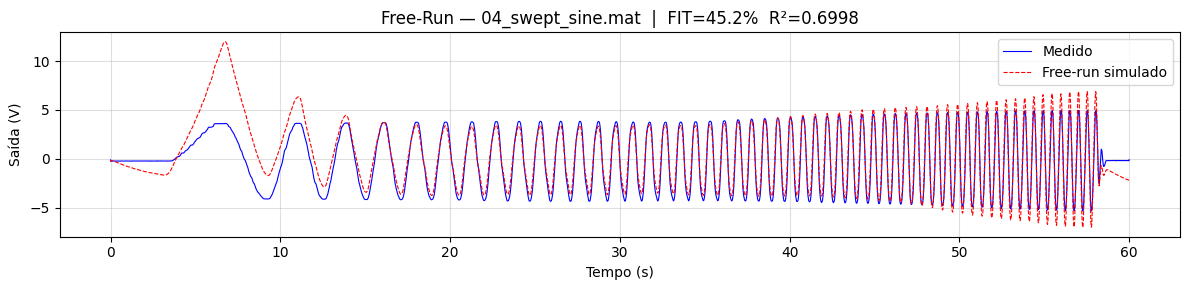

  03_random_steps_04.mat            RMSE:1.01018  R²:0.82375  FIT:58.02%


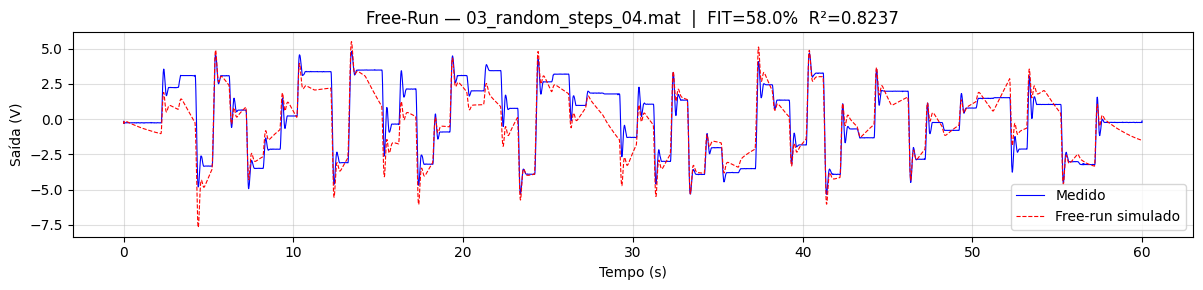


--- Teste | One-Step Ahead ---
  03_random_steps_04.mat            RMSE:0.02019  R²:0.99993  FIT:99.16%

--- Teste | Free-Run ---
  03_random_steps_04.mat            RMSE:1.01018  R²:0.82375  FIT:58.02%


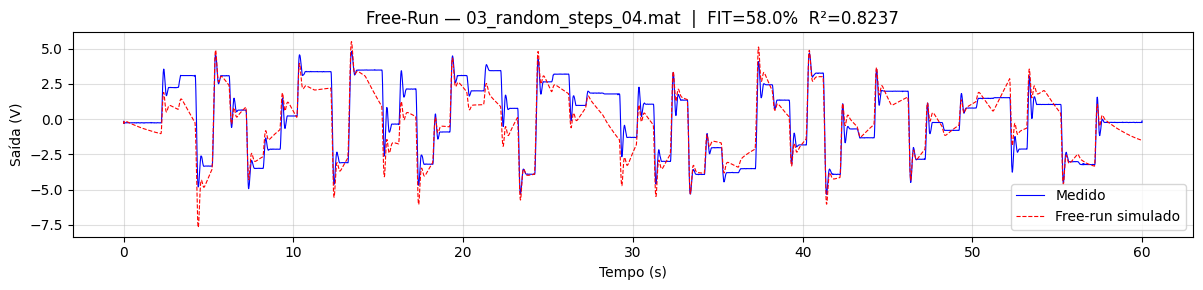


>>> FIT FR médio (validação): 51.61%
  ⚠ FIT entre 50–65%: rode o grid search antes de avançar.


In [ ]:
# =============================================================================
# CÉLULA 2C — TREINAMENTO INICIAL (OSA + SEM)
# =============================================================================
# Treina com a configuração padrão definida na Célula 0C.
# O grid search na Célula 2E pode substituir este modelo se encontrar algo melhor.
# =============================================================================

print('=== Estágio 1: FROLS + Ridge (OSA) + SEM ===')
model, X_base_train, y_train_narx = fit_narx_polynomial(
    config['files_train'], config, verbose=True
)
print_model_terms(model)

# Métricas OSA no conjunto de treino
Phi_tr, _, _, _ = build_poly_library(X_base_train, model['var_names'],
                                      model['degree'], model['include_bias'])
yhat_tr = Phi_tr[:, model['selected_idx']] @ model['theta']
print(f'\nTreino OSA — RMSE: {np.sqrt(mean_squared_error(y_train_narx, yhat_tr)):.6f}  '
      f'R²: {r2_score(y_train_narx, yhat_tr):.6f}')

print('\n=== Avaliação pós-treino ===')
osa_val = evaluate_osa(config['files_val'],  model, config, title='Validação')
fr_val  = evaluate_free_run(config['files_val'],  model, config, title='Validação', plot=True)
osa_tst = evaluate_osa(config['files_test'], model, config, title='Teste')
fr_tst  = evaluate_free_run(config['files_test'], model, config, title='Teste', plot=True)

fit_medio = fr_val['FIT_FR_%'].mean()
print(f'\n>>> FIT FR médio (validação): {fit_medio:.2f}%')
if fit_medio >= 65:
    print('  ✓ Modelo adequado para prosseguir para o NMPC.')
elif fit_medio >= 50:
    print('  ⚠ FIT entre 50–65%: rode o grid search antes de avançar.')
else:
    print('  ✗ FIT < 50%: revise os dados ou a estrutura do modelo.')


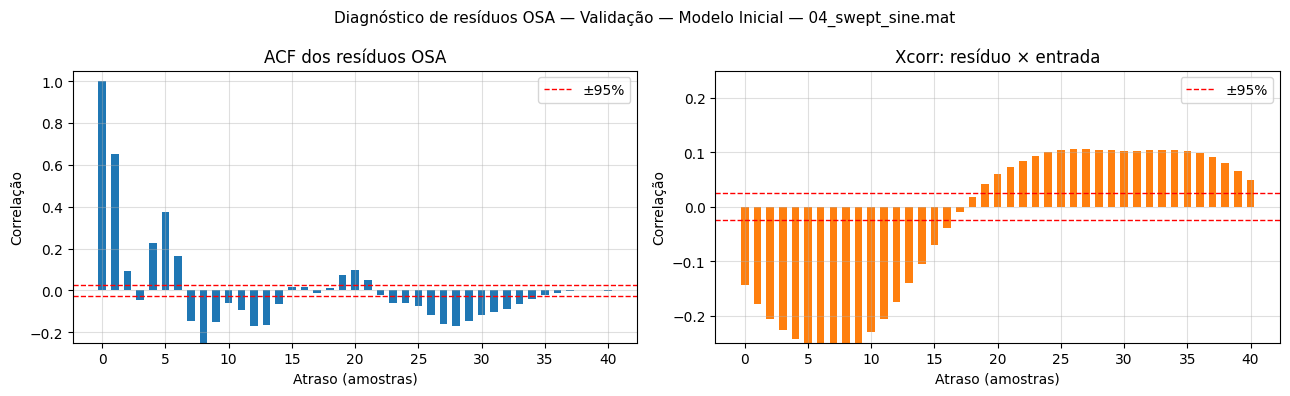

  04_swept_sine.mat: ACF fora=72.5%  xcorr fora=95.0%
  → Dinâmica não capturada. Considere aumentar ny, nu ou degree.


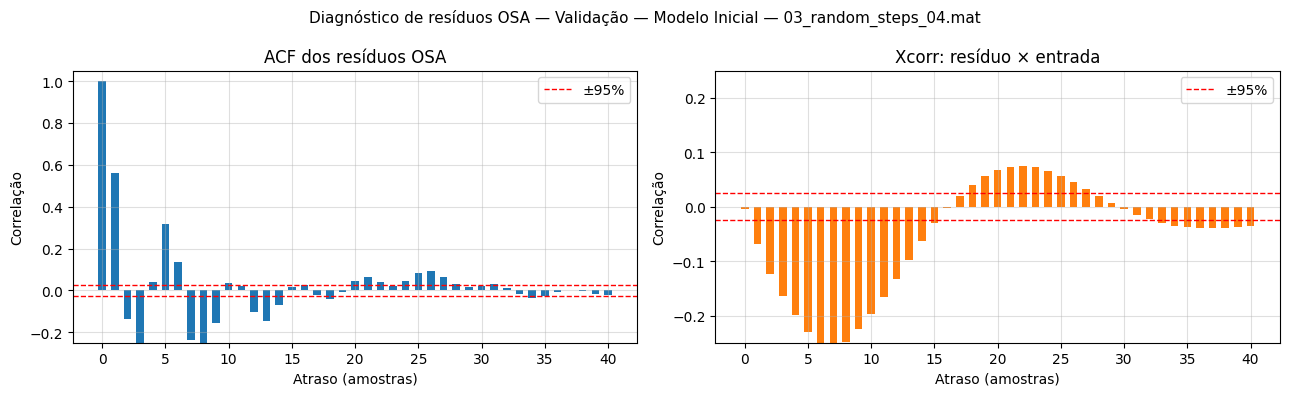

  03_random_steps_04.mat: ACF fora=62.5%  xcorr fora=82.5%
  → Dinâmica não capturada. Considere aumentar ny, nu ou degree.


In [ ]:
# =============================================================================
# CÉLULA 2D — DIAGNÓSTICO DE RESÍDUOS
# =============================================================================
# Critérios de qualidade além de RMSE e FIT%:
#
# ACF dos resíduos OSA:
#   Deve cair rapidamente para zero. Se muitos lags forem significativos,
#   o modelo não capturou toda a dinâmica temporal do sistema.
#   Solução: aumentar ny (mais memória da saída).
#
# Correlação cruzada resíduo × entrada:
#   Deve ser próxima de zero. Se correlacionada, a dinâmica de entrada
#   não foi totalmente capturada pelo modelo.
#   Solução: aumentar nu ou degree.
#
# Nota: no swept_sine (excitação de banda larga), valores acima de 5%
# são esperados para modelos polinomiais de ordem baixa — isso reflete
# uma limitação estrutural do modelo, não necessariamente um erro de
# implementação. O critério de avanço continua sendo o FIT_FR%.
# =============================================================================

plot_residual_diagnostics(config['files_val'], model, config,
                          n_lags=40, title='Validação — Modelo Inicial')


In [ ]:
# =============================================================================
# CÉLULA 2E — GRID SEARCH COM PENALIZAÇÃO DE INSTABILIDADE
# =============================================================================
# Varre combinações de (ny, nu, degree, n_terms) com SEM desligado para
# velocidade. O SEM é aplicado apenas ao modelo final selecionado.
#
# Critério de seleção:
#   RMSE_FR_penalizado = RMSE_FR_medio + penalidade_polo
#   onde penalidade_polo = max(0, Σ|coef_y| - 0.98) × 100
#
# Observação baseada nos seus dados:
#   nu=4 foi removido por ser consistentemente instável no free-run.
#   degree=2 produz free-run instável (FIT < 0%) — incluído apenas para referência.
# =============================================================================

configs_grid = [
    {'ny': 2, 'nu': 3, 'degree': 3, 'n_terms':  6},
    {'ny': 2, 'nu': 3, 'degree': 3, 'n_terms':  8},
    {'ny': 2, 'nu': 3, 'degree': 3, 'n_terms': 10},
    {'ny': 2, 'nu': 3, 'degree': 3, 'n_terms': 12},
    {'ny': 3, 'nu': 3, 'degree': 3, 'n_terms':  8},
    {'ny': 3, 'nu': 3, 'degree': 3, 'n_terms': 10},
    {'ny': 3, 'nu': 3, 'degree': 3, 'n_terms': 12},
    {'ny': 4, 'nu': 3, 'degree': 3, 'n_terms': 10},
    {'ny': 4, 'nu': 3, 'degree': 3, 'n_terms': 12},
    {'ny': 2, 'nu': 3, 'degree': 4, 'n_terms':  8},
    {'ny': 2, 'nu': 3, 'degree': 4, 'n_terms': 10},
    {'ny': 3, 'nu': 3, 'degree': 4, 'n_terms': 10},
]

results_grid, models_grid = [], []

for cg in tqdm(configs_grid, desc='Grid NARX (sem SEM)'):
    cfg_try = {**config, **cg, 'use_sem': False}
    try:
        m_try, _, _ = fit_narx_polynomial(cfg_try['files_train'], cfg_try, verbose=False)
        df_fr  = evaluate_free_run(cfg_try['files_val'], m_try, cfg_try, plot=False, verbose=False)
        df_osa = evaluate_osa(cfg_try['files_val'], m_try, cfg_try, verbose=False)
        pen    = dominant_pole_penalty(m_try, threshold=0.98)
        results_grid.append({**cg,
            'RMSE_FR_medio':      df_fr['RMSE_FR'].mean(),
            'FIT_FR_medio_%':     df_fr['FIT_FR_%'].mean(),
            'RMSE_OSA_medio':     df_osa['RMSE_OSA'].mean(),
            'FIT_OSA_medio_%':    df_osa['FIT_OSA_%'].mean(),
            'penalidade_polo':    pen,
            'RMSE_FR_penalizado': df_fr['RMSE_FR'].mean() + pen,
        })
        models_grid.append(m_try)
    except Exception as e:
        print(f'  [FALHA] {cg} — {e}')

results_grid_df = (pd.DataFrame(results_grid)
                   .sort_values('RMSE_FR_penalizado').reset_index(drop=True))
print('\nResultados do grid (ordenado por RMSE_FR_penalizado):')
print(results_grid_df.to_string(index=False))


Grid NARX (sem SEM):   0%|          | 0/12 [00:00<?, ?it/s]


Resultados do grid (ordenado por RMSE_FR_penalizado):
 ny  nu  degree  n_terms  RMSE_FR_medio  FIT_FR_medio_%  RMSE_OSA_medio  FIT_OSA_medio_%  penalidade_polo  RMSE_FR_penalizado
  2   3       3       10       1.692116       38.798565        0.017950        99.331409       165.690371          167.382488
  2   3       4       10       1.692116       38.798565        0.017950        99.331409       165.690371          167.382488
  2   3       3       12       1.382845       49.606489        0.017925        99.331156       167.461379          168.844224
  2   3       3        8       8.903286     -237.677765        0.018232        99.320490       160.722623          169.625908
  2   3       4        8       8.903286     -237.677765        0.018232        99.320490       160.722623          169.625908
  2   3       3        6      13.560466     -399.196567        0.017717        99.335474       167.376274          180.936740
  3   3       3       10      13.776085     -416.770244        

Melhor estrutura do grid:
  ny: 2.0
  nu: 3.0
  degree: 3.0
  n_terms: 10.0
  RMSE_FR_medio: 1.6921162947069583
  FIT_FR_medio_%: 38.79856487730356
  penalidade_polo: 165.69037134360346

=== Retreino: FROLS + Ridge (OSA) ===

--- Pré-SEM | Free-Run ---
  04_swept_sine.mat                 RMSE:2.15971  R²:0.48860  FIT:28.49%
  03_random_steps_04.mat            RMSE:1.22452  R²:0.74101  FIT:49.11%

=== Retreino: SEM (minimização do erro de free-run) ===
  SEM: RMSE free-run inicial = 1.382139


  SEM L-BFGS-B:   0%|          | 0/800 [00:00<?, ?it/s]

  SEM: RMSE free-run final   = 0.483895
  SEM: convergiu=True  msg="CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH"
  SEM: redução RMSE = 65.0%

--- Pós-SEM | Free-Run ---
  04_swept_sine.mat                 RMSE:1.69872  R²:0.68362  FIT:43.75%


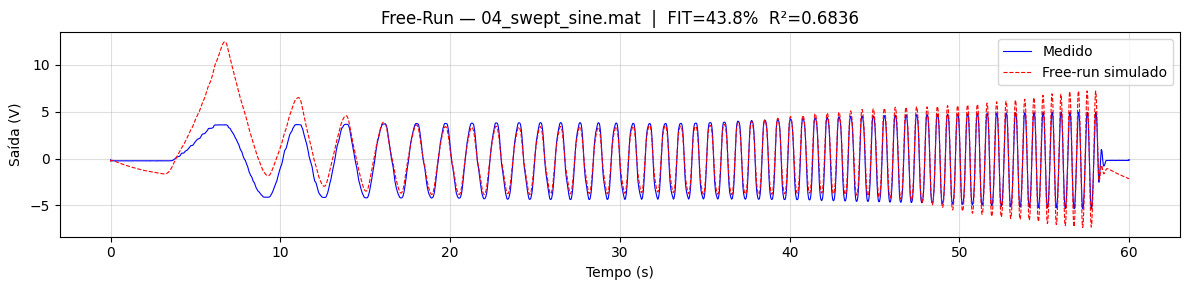

  03_random_steps_04.mat            RMSE:1.01646  R²:0.82155  FIT:57.76%


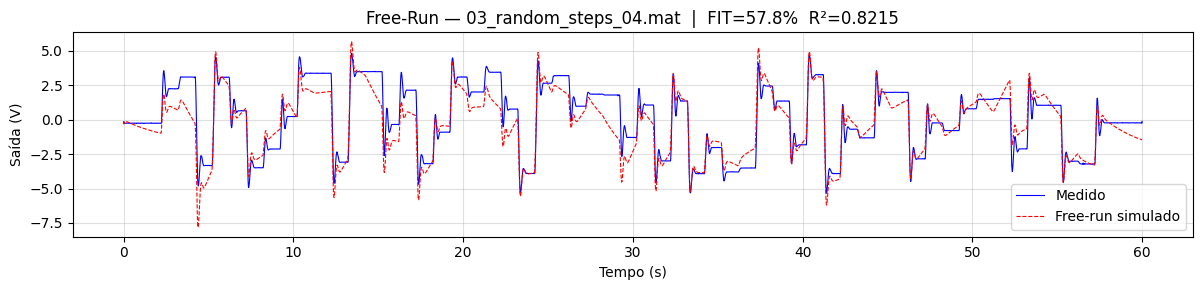


=== Comparação antes × depois do SEM ===
               arquivo  RMSE_FR_antes  FIT%_antes  RMSE_FR_depois  FIT%_depois
     04_swept_sine.mat       2.159710    28.48789        1.698718    43.752213
03_random_steps_04.mat       1.224523    49.10924        1.016464    57.756101

✓ SEM melhorou o free-run. Usando modelo refinado.

Modelo NARX polinomial — termos selecionados:
  +1.81808557e+00  ×  y(k-1)
  -8.18672366e-01  ×  y(k-2)
  +7.86989970e-03  ×  u(k-3)
  -7.16828412e-03  ×  1
  +9.89928766e-03  ×  y(k-1)^2 u(k-3)
  +1.31233391e-02  ×  y(k-2)^2 u(k-3)
  -2.30433715e-02  ×  y(k-1) y(k-2) u(k-3)
  +2.14575613e-05  ×  u(k-2)^3
  +3.88738916e-03  ×  y(k-1)^2 u(k-1)
  -3.77433610e-03  ×  y(k-1) y(k-2) u(k-1)
  (10 termos  |  ny=2  nu=3  grau=3)
  Coef. lineares y: ['+1.8181', '-0.8187']
  Soma = +0.9994  |  Σ|coef| = 2.6368
  ⚠ Polo dominante próximo do círculo unitário — free-run pode ser instável.


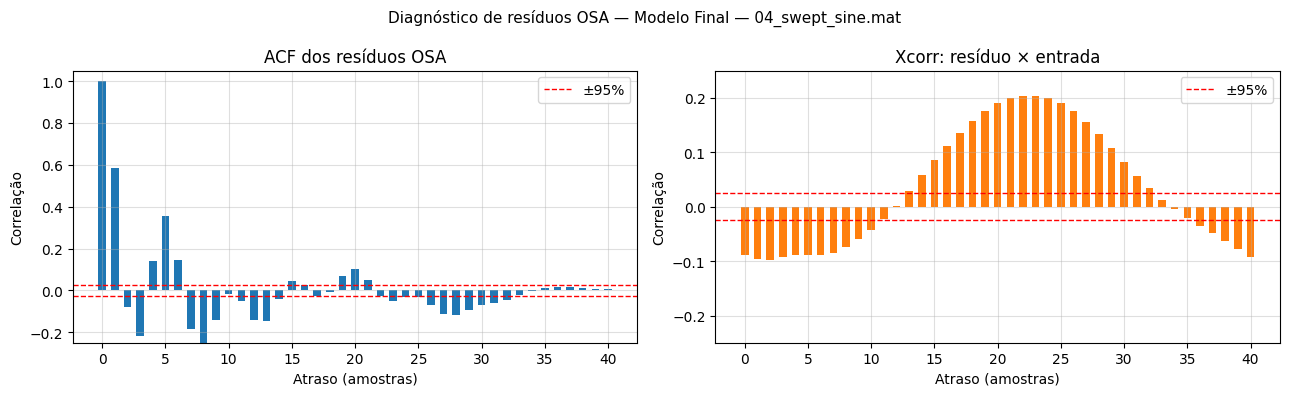

  04_swept_sine.mat: ACF fora=72.5%  xcorr fora=87.5%
  → Dinâmica não capturada. Considere aumentar ny, nu ou degree.


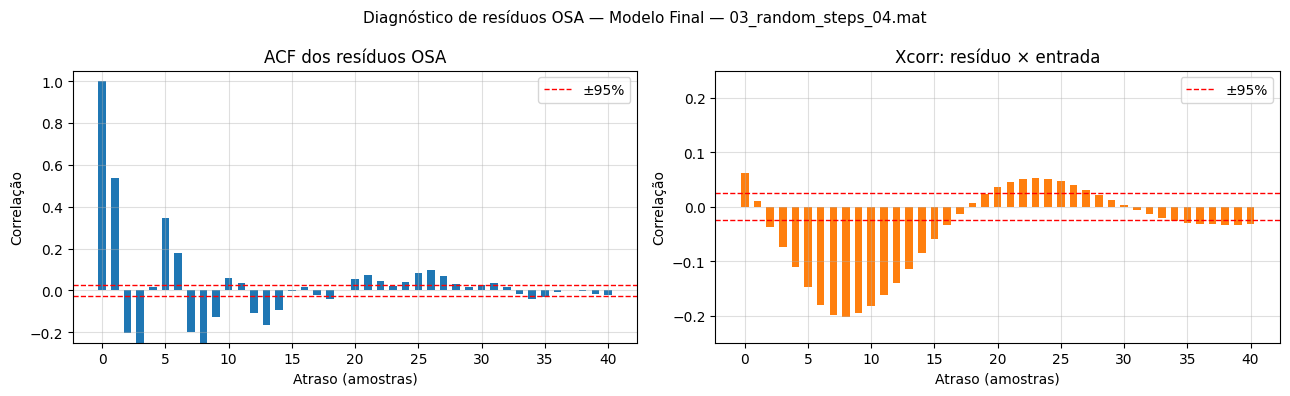

  03_random_steps_04.mat: ACF fora=65.0%  xcorr fora=75.0%
  → Dinâmica não capturada. Considere aumentar ny, nu ou degree.


In [ ]:
# =============================================================================
# CÉLULA 2F — SELECIONAR MELHOR MODELO E APLICAR SEM
# =============================================================================
# 1. Identifica a melhor estrutura (ny, nu, degree, n_terms) pelo grid.
# 2. Retreina com os 4 arquivos de treino.
# 3. Aplica o SEM para refinar theta pelo erro de free-run.
# 4. Compara antes × depois do SEM e decide qual modelo usar.
# =============================================================================

if len(results_grid_df) > 0:
    best_row = results_grid_df.iloc[0]
    best_cfg = {**config,
                'ny': int(best_row['ny']), 'nu': int(best_row['nu']),
                'degree': int(best_row['degree']), 'n_terms': int(best_row['n_terms'])}

    print('Melhor estrutura do grid:')
    for k in ['ny','nu','degree','n_terms','RMSE_FR_medio','FIT_FR_medio_%','penalidade_polo']:
        print(f'  {k}: {best_row[k]}')

    # Estágio 1: FROLS + Ridge
    print('\n=== Retreino: FROLS + Ridge (OSA) ===')
    model_osa, X_base_train, y_train_narx = fit_narx_polynomial(
        best_cfg['files_train'], {**best_cfg, 'use_sem': False}, verbose=True)
    fr_antes = evaluate_free_run(best_cfg['files_val'], model_osa, best_cfg,
                                  title='Pré-SEM', plot=False, verbose=True)

    # Estágio 2: SEM
    print('\n=== Retreino: SEM (minimização do erro de free-run) ===')
    model_sem = refine_theta_sem(model_osa, best_cfg['files_train'], best_cfg)
    fr_depois = evaluate_free_run(best_cfg['files_val'], model_sem, best_cfg,
                                   title='Pós-SEM', plot=True, verbose=True)

    print('\n=== Comparação antes × depois do SEM ===')
    print(pd.DataFrame({
        'arquivo':        fr_antes['arquivo'],
        'RMSE_FR_antes':  fr_antes['RMSE_FR'],
        'FIT%_antes':     fr_antes['FIT_FR_%'],
        'RMSE_FR_depois': fr_depois['RMSE_FR'],
        'FIT%_depois':    fr_depois['FIT_FR_%'],
    }).to_string(index=False))

    if fr_depois['FIT_FR_%'].mean() > fr_antes['FIT_FR_%'].mean():
        model = model_sem
        print('\n✓ SEM melhorou o free-run. Usando modelo refinado.')
    else:
        model = model_osa
        print('\n⚠ SEM não melhorou. Usando modelo OSA. Tente ajustar lambda_sem.')

    config.update(best_cfg)
    print_model_terms(model)
    plot_residual_diagnostics(config['files_val'], model, config,
                              n_lags=40, title='Modelo Final')
else:
    print('Grid sem resultados. Mantendo modelo da Célula 2C.')


In [ ]:
# =============================================================================
# CÉLULA 2G — AJUSTE FINO DO LAMBDA_SEM (opcional)
# =============================================================================
# Execute se o FIT_FR% após o SEM ainda estiver abaixo de 65%.
# Testa 5 valores de lambda_sem e exibe os resultados.
# Após identificar o melhor lambda, atualize config['lambda_sem']
# e reexecute a Célula 2F.
# =============================================================================

RODAR_VARREDURA_LAMBDA = True   # mude para True para executar

if RODAR_VARREDURA_LAMBDA and 'model_osa' in dir():
    rows_lam = []
    for lam in tqdm([1e-5, 1e-4, 1e-3, 1e-2, 1e-1], desc='Varredura lambda_sem'):
        cfg_lam = {**best_cfg, 'use_sem': True, 'lambda_sem': lam, 'sem_maxiter': 300}
        m_lam   = refine_theta_sem(model_osa, cfg_lam['files_train'], cfg_lam)
        df_fr   = evaluate_free_run(cfg_lam['files_val'], m_lam, cfg_lam,
                                     plot=False, verbose=False)
        rows_lam.append({'lambda_sem': lam, 'RMSE_FR': df_fr['RMSE_FR'].mean(),
                         'FIT_FR_%': df_fr['FIT_FR_%'].mean()})
    df_lam = pd.DataFrame(rows_lam).sort_values('RMSE_FR')
    print('\nResultados da varredura de lambda_sem:')
    print(df_lam.to_string(index=False))
    print(f'\n→ Melhor lambda_sem: {df_lam.iloc[0]["lambda_sem"]}')
    print('  Atualize config["lambda_sem"] e reexecute a Célula 2F.')
else:
    print('Varredura desligada (RODAR_VARREDURA_LAMBDA = False).')


Varredura lambda_sem:   0%|          | 0/5 [00:00<?, ?it/s]

  SEM: RMSE free-run inicial = 0.922339


  SEM L-BFGS-B:   0%|          | 0/300 [00:00<?, ?it/s]

  SEM: RMSE free-run final   = 0.499040
  SEM: convergiu=True  msg="CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH"
  SEM: redução RMSE = 45.9%
  SEM: RMSE free-run inicial = 0.922339


  SEM L-BFGS-B:   0%|          | 0/300 [00:00<?, ?it/s]

...

  SEM: RMSE free-run final   = 0.500514
  SEM: convergiu=True  msg="CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH"
  SEM: redução RMSE = 45.7%
  SEM: RMSE free-run inicial = 0.922339


  SEM L-BFGS-B:   0%|          | 0/300 [00:00<?, ?it/s]

  SEM: RMSE free-run final   = 0.498647
  SEM: convergiu=True  msg="CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH"
  SEM: redução RMSE = 45.9%
  SEM: RMSE free-run inicial = 0.922339


  SEM L-BFGS-B:   0%|          | 0/300 [00:00<?, ?it/s]

  SEM: RMSE free-run final   = 0.513390
  SEM: convergiu=True  msg="CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH"
  SEM: redução RMSE = 44.3%

Resultados da varredura de lambda_sem:
 lambda_sem  RMSE_FR  FIT_FR_%
    0.00010 0.945388 64.879414
    0.01000 0.945460 64.877637
    0.00100 0.960648 64.384845
    0.00001 0.963612 64.236274
    0.10000 2.821945  2.442298

→ Melhor lambda_sem: 0.0001
  Atualize config["lambda_sem"] e reexecute a Célula 2F.


## Seção 3 — Persistência do Modelo NARX

In [ ]:
# =============================================================================
# CÉLULA 3A — SALVAR MODELO NARX NO DRIVE
# =============================================================================
# Salva dois arquivos:
#   narx_model.pkl  — modelo completo (use para continuar o pipeline)
#   narx_model.json — resumo legível (use para documentação e artigo)
#
# Execute após confirmar que o modelo é satisfatório (FIT_FR% ≥ 65%).
# =============================================================================

SALVAR_NARX = True

if SALVAR_NARX:
    save_dir = Path(PATH_SAVE)
    save_dir.mkdir(parents=True, exist_ok=True)

    # .pkl — preserva arrays NumPy exatamente
    pkl_path = save_dir / 'narx_model_final1.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(model, f)

    # .json — resumo legível por humanos
    json_path = save_dir / 'narx_model_final1.json'
    model_json = {
        'ny': model['ny'], 'nu': model['nu'],
        'degree': model['degree'], 'include_bias': model['include_bias'],
        'n_terms': len(model['theta']),
        'theta': model['theta'].tolist(),
        'selected_names': model['selected_names'],
        'selected_powers': model['selected_powers'].tolist(),
        'var_names': model['var_names'],
        'ridge_alpha': config.get('ridge_alpha'),
        'lambda_sem':  config.get('lambda_sem'),
        'Ts': Ts,
    }
    with open(json_path, 'w') as f:
        json.dump(model_json, f, indent=2)

    print(f'✓ Modelo salvo em:')
    print(f'  {pkl_path}')
    print(f'  {json_path}')
else:
    print('Salvamento desativado (SALVAR_NARX = False).')


✓ Modelo salvo em:
  /content/drive/MyDrive/bab_dados_mat/narx_model_final1.pkl
  /content/drive/MyDrive/bab_dados_mat/narx_model_final1.json


In [ ]:
# =============================================================================
# CÉLULA 3B — CARREGAR MODELO NARX DO DRIVE (nova sessão)
# =============================================================================
# Execute esta célula quando reabrir o Colab em uma nova sessão.
# Pré-requisito: rerrodar as células 0B, 0C, 1A, 2A, 2B antes desta.
# Após carregar, continue a partir da Seção 4 (NMPC).
# =============================================================================

CARREGAR_NARX = True   # mude para True quando for recarregar

if CARREGAR_NARX:
    pkl_path = Path(PATH_SAVE) / 'narx_model_final1.pkl'
    shutil.copy(str(pkl_path), 'narx_model_final1.pkl')
    with open('narx_model_final1.pkl', 'rb') as f:
        model = pickle.load(f)
    print(f'✓ Modelo carregado de: {pkl_path}')
    print(f'  ny={model["ny"]}  nu={model["nu"]}  '
          f'degree={model["degree"]}  termos={len(model["theta"])}')
    print_model_terms(model)
    config.update({'ny': model['ny'], 'nu': model['nu'],
                   'degree': model['degree'], 'include_bias': model['include_bias']})
else:
    print('Carregamento desativado (CARREGAR_NARX = False).')
    print('Mude para True quando reabrir uma nova sessão.')


✓ Modelo carregado de: /content/drive/MyDrive/bab_dados_mat/narx_model_final1.pkl
  ny=2  nu=3  degree=3  termos=10

Modelo NARX polinomial — termos selecionados:
  +1.81808557e+00  ×  y(k-1)
  -8.18672366e-01  ×  y(k-2)
  +7.86989970e-03  ×  u(k-3)
  -7.16828412e-03  ×  1
  +9.89928766e-03  ×  y(k-1)^2 u(k-3)
  +1.31233391e-02  ×  y(k-2)^2 u(k-3)
  -2.30433715e-02  ×  y(k-1) y(k-2) u(k-3)
  +2.14575613e-05  ×  u(k-2)^3
  +3.88738916e-03  ×  y(k-1)^2 u(k-1)
  -3.77433610e-03  ×  y(k-1) y(k-2) u(k-1)
  (10 termos  |  ny=2  nu=3  grau=3)
  Coef. lineares y: ['+1.8181', '-0.8187']
  Soma = +0.9994  |  Σ|coef| = 2.6368
  ⚠ Polo dominante próximo do círculo unitário — free-run pode ser instável.


## Seção 4 — NMPC Professor

In [ ]:
# =============================================================================
# CÉLULA 4A — FUNÇÕES DE TRANSIÇÃO DE ESTADO (CasADi + NumPy)
# =============================================================================
# O estado do NMPC é o vetor de atrasos do modelo NARX:
#   x = [y(k), y(k-1), ..., y(k-ny+1), u(k-1), ..., u(k-nu)]
#   dim(x) = ny + nu
#
# Duas versões da transição de estado:
#   - CasADi (simbólica): usada dentro do otimizador NMPC
#   - NumPy (numérica): usada na simulação e na geração do dataset
# =============================================================================

if not CASADI_OK:
    print('⚠ CasADi não disponível. Células de NMPC serão ignoradas.')


def narx_eval_casadi(base_vars, model):
    """Avalia o NARX com variáveis simbólicas CasADi (MX/SX)."""
    y_pred = 0
    for coef, pows in zip(model['theta'], model['selected_powers']):
        term = 1
        for var, p in zip(base_vars, pows):
            if p != 0: term = term * (var ** int(p))
        y_pred = y_pred + float(coef) * term
    return y_pred


def state_transition_casadi(x, u_new, model):
    """Transição x(k+1) = f_NARX(x(k), u(k)) — versão simbólica CasADi."""
    ny, nu = model['ny'], model['nu']
    base   = [x[i] for i in range(ny)] + [u_new] + [x[ny+j] for j in range(nu-1)]
    y_next = narx_eval_casadi(base, model)
    ns = [y_next] + [x[i] for i in range(ny-1)] + [u_new] + [x[ny+j] for j in range(nu-1)]
    return ca.vertcat(*ns)


def state_transition_numpy(x, u_new, model):
    """Transição x(k+1) = f_NARX(x(k), u(k)) — versão numérica NumPy."""
    ny, nu = model['ny'], model['nu']
    base   = list(x[:ny]) + [u_new] + list(x[ny:ny+nu-1])
    y_next = predict_from_base_numpy(np.array(base), model)
    return np.asarray([y_next] + list(x[:ny-1]) + [u_new] + list(x[ny:ny+nu-1]))


print('Funções de transição definidas.')
print(f'Dimensão do estado: nx = ny + nu = {config["ny"]} + {config["nu"]} = {config["ny"]+config["nu"]}')


Funções de transição definidas.
Dimensão do estado: nx = ny + nu = 2 + 3 = 5


In [ ]:
# =============================================================================
# CÉLULA 4B — CONSTRUÇÃO DO SOLVER NMPC
# =============================================================================
# Formulação do problema de otimização NMPC:
#
#   min_{U}  Σ_{j=0}^{N-1} [Q·e_j² + R·u_j² + Rd·(Δu_j)²] + QN·e_N²
#
#   s.a.:  x_{j+1} = f_NARX(x_j, u_j)
#          u_min ≤ u_j ≤ u_max
#          |Δu_j| ≤ du_max
#          y_min ≤ y_j ≤ y_max
#
# Parâmetros atuais (ajustados para rastreamento suave):
#   Q=80, QN=300: pesos do erro de rastreamento
#   R=0.10: penaliza esforço de controle
#   Rd=2.0: penaliza variação du (suaviza o sinal de controle)
#   du_max=0.6: variação máxima de u por passo
#
# Sugestão de ajuste:
#   - Aumentar Rd (ex: 10–50) para reduzir chattering no sinal de controle
#   - Reduzir Q (ex: 50–60) para reduzir overshoot nos degraus
#   - Aumentar N (ex: 60–80) para melhorar antecipação em transientes
# =============================================================================

N      = 60      # horizonte de predição
Q      = 80.0    # peso erro rastreamento
QN     = 300.0   # peso erro terminal
R      = 0.10    # peso esforço de controle
Rd     = 5.0    # peso variação du (suavidade) 10.0
du_max = 1.2     # variação máxima de u por passo (V/amostra) 0.6

print(f'Horizonte de predição: N = {N} amostras → {N*Ts:.3f} s')
print(f'Pesos: Q={Q}  QN={QN}  R={R}  Rd={Rd}  du_max={du_max}')


def build_nmpc_solver(model, cfg, N=50, Q=80., QN=300., R=0.10, Rd=2., du_max=0.6):
    if not CASADI_OK: raise RuntimeError('CasADi não disponível.')
    nx    = model['ny'] + model['nu']
    X0    = ca.MX.sym('X0', nx)
    REF   = ca.MX.sym('REF')
    Uprev = ca.MX.sym('Uprev')
    U     = ca.MX.sym('U', N)
    x, cost, g, lbg, ubg = X0, 0, [], [], []
    u_ant = Uprev
    for k in range(N):
        uk = U[k]; du = uk - u_ant
        cost += Rd * du**2
        g.append(du); lbg.append(-du_max); ubg.append(du_max)
        x    = state_transition_casadi(x, uk, model)
        cost += Q * (x[0] - REF)**2 + R * uk**2
        g.append(x[0]); lbg.append(cfg['y_min']); ubg.append(cfg['y_max'])
        u_ant = uk
    cost += QN * (x[0] - REF)**2
    nlp  = {'x': U, 'f': cost, 'g': ca.vertcat(*g),
            'p': ca.vertcat(X0, REF, Uprev)}
    opts = {'ipopt.print_level': 0, 'print_time': 0,
            'ipopt.max_iter': 100, 'ipopt.tol': 1e-5}
    solver = ca.nlpsol('solver', 'ipopt', nlp, opts)
    return solver, np.full(N, cfg['u_min']), np.full(N, cfg['u_max']), \
           np.array(lbg), np.array(ubg)


if CASADI_OK:
    solver, lbx_nmpc, ubx_nmpc, lbg_nmpc, ubg_nmpc = build_nmpc_solver(
        model, config, N=N, Q=Q, QN=QN, R=R, Rd=Rd, du_max=du_max)
    print(f'\n✓ Solver NMPC criado. Variáveis de decisão: {N}  |  Restrições: {len(lbg_nmpc)}')


Horizonte de predição: N = 60 amostras → 0.600 s
Pesos: Q=80.0  QN=300.0  R=0.1  Rd=5.0  du_max=1.2

✓ Solver NMPC criado. Variáveis de decisão: 60  |  Restrições: 120


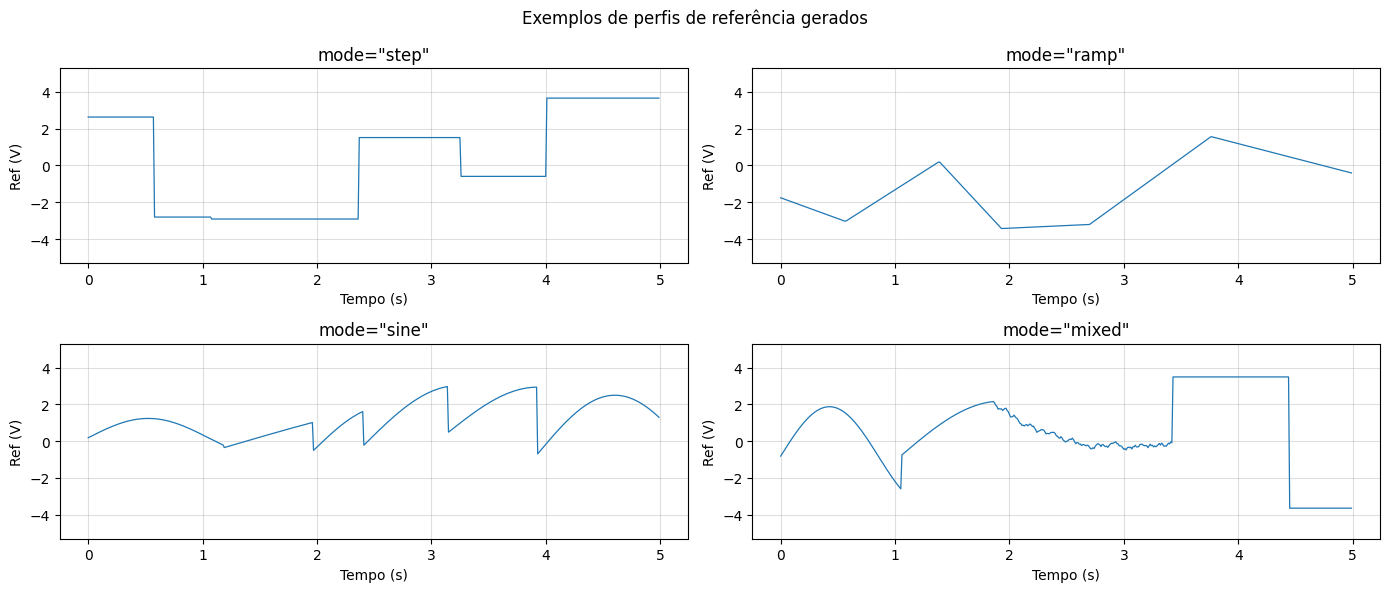

In [ ]:
# =============================================================================
# CÉLULA 4C — GERADOR DE REFERÊNCIAS
# =============================================================================
# Gera perfis de referência mistos (degrau, rampa, seno, aleatório suavizado)
# para a simulação do NMPC e para o dataset de treinamento do MPC Aproximado.
#
# A diversidade de tipos de referência é importante para que o MPC Aproximado
# aprenda a política do NMPC em diferentes regimes de operação.
# =============================================================================

rng = np.random.default_rng(42)

def generate_reference_profile(num_steps, Ts, y_min=-4., y_max=4.,
                                mode='mixed', seed=None,
                                min_seg_s=0.25, max_seg_s=1.50):
    _rng    = np.random.default_rng(seed) if seed is not None else rng
    ref     = np.zeros(num_steps, dtype=float)
    t       = np.arange(num_steps) * Ts
    min_seg = max(5, int(min_seg_s / Ts))
    max_seg = max(min_seg + 1, int(max_seg_s / Ts))
    k, cur  = 0, float(_rng.uniform(y_min, y_max))
    while k < num_steps:
        seg = min(int(_rng.integers(low=min_seg, high=max_seg)), num_steps - k)
        ch  = str(_rng.choice(['step','ramp','sine','random'],
                               p=[0.35, 0.35, 0.20, 0.10])) if mode=='mixed' else mode
        if ch == 'step':
            cur = float(_rng.uniform(y_min, y_max)); ref[k:k+seg] = cur
        elif ch == 'ramp':
            tgt = float(_rng.uniform(y_min, y_max))
            ref[k:k+seg] = np.linspace(cur, tgt, seg); cur = tgt
        elif ch == 'sine':
            amp = float(_rng.uniform(0.8, 3.5)); off = float(_rng.uniform(-1., 1.))
            fhz = float(_rng.uniform(0.03, 0.60))
            ref[k:k+seg] = np.clip(off + amp*np.sin(2*np.pi*fhz*(t[k:k+seg]-t[k])),
                                   y_min, y_max)
            cur = float(ref[k+seg-1])
        elif ch == 'random':
            tmp = np.zeros(seg); tmp[0] = cur
            vals = _rng.uniform(y_min, y_max, size=seg)
            for i in range(1, seg): tmp[i] = 0.97*tmp[i-1] + 0.03*vals[i]
            ref[k:k+seg] = np.clip(tmp, y_min, y_max); cur = float(ref[k+seg-1])
        k += seg
    return np.clip(ref, y_min, y_max)


# Visualiza exemplos dos quatro tipos de referência
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle('Exemplos de perfis de referência gerados', fontsize=12)
for ax, mode, seed in zip(axes.flat,
                          ['step', 'ramp', 'sine', 'mixed'],
                          [10, 20, 30, 42]):
    r = generate_reference_profile(500, Ts, mode=mode, seed=seed)
    ax.plot(np.arange(500)*Ts, r, lw=0.9)
    ax.set_title(f'mode="{mode}"'); ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Ref (V)'); ax.grid(True, alpha=0.4)
    ax.set_ylim(config['y_min']-0.3, config['y_max']+0.3)
plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# CÉLULA 4D — SIMULAÇÃO DO NMPC PROFESSOR E GERAÇÃO DO DATASET
# =============================================================================
# Gera o dataset de pares (estado + referência → controle ótimo) para treinar
# o MPC Aproximado.
#
# Estratégia de geração:
#   - num_steps_dataset amostras com referência mista (degrau/rampa/seno)
#   - Warm start: sequência ótima deslocada em 1 passo (melhora desempenho)
#   - Cold start automático após 10 falhas consecutivas do solver
#   - Falhas (solver_ok=0) são excluídas do treino da MLP
#
# ATENÇÃO: num_steps_dataset=20000 pode levar 30–90 min no Colab.
# O dataset é salvo em CSV automaticamente ao final.
# =============================================================================

num_steps_dataset = 10000   # mínimo recomendado: 20000
ref_dataset = generate_reference_profile(num_steps_dataset, Ts, seed=0)

nx            = model['ny'] + model['nu']
columns_state = [f'x{i}' for i in range(nx)]
x_sim, u_prev, u_guess = np.zeros(nx), 0., np.zeros(N)
hist_x, hist_y, hist_u, hist_ref, hist_status = [], [], [], [], []


def solve_nmpc_one_step(x, ref, u_prev, u_guess):
    p   = np.concatenate([np.asarray(x), [float(ref), float(u_prev)]])
    sol = solver(x0=u_guess, lbx=lbx_nmpc, ubx=ubx_nmpc,
                 lbg=lbg_nmpc, ubg=ubg_nmpc, p=p)
    Uopt = np.array(sol['x']).squeeze()
    return float(Uopt[0]), Uopt


if CASADI_OK:
    fail_streak = 0
    t_ini = time.time()
    for k in tqdm(range(num_steps_dataset), desc='NMPC professor'):
        ref_k = float(ref_dataset[k])
        try:
            u_opt, Uopt = solve_nmpc_one_step(x_sim, ref_k, u_prev, u_guess)
            u_guess = np.r_[Uopt[1:], Uopt[-1]]; status = 1; fail_streak = 0
        except Exception:
            u_opt = u_prev; status = 0; fail_streak += 1
            if fail_streak >= 10: u_guess = np.zeros(N)
        hist_x.append(x_sim.copy()); hist_ref.append(ref_k)
        hist_u.append(u_opt); hist_status.append(status)
        x_sim = state_transition_numpy(x_sim, u_opt, model)
        x_sim[0] = np.clip(x_sim[0], config['y_min'], config['y_max'])
        u_prev = u_opt; hist_y.append(x_sim[0])

    t_total = time.time() - t_ini
    hist_x = np.asarray(hist_x); hist_ref = np.asarray(hist_ref)
    hist_u = np.asarray(hist_u); hist_y   = np.asarray(hist_y)
    hist_status = np.asarray(hist_status)

    df_dataset = pd.DataFrame(hist_x, columns=columns_state)
    df_dataset['ref'] = hist_ref; df_dataset['u_optimal'] = hist_u
    df_dataset['y_next'] = hist_y; df_dataset['solver_ok'] = hist_status

    taxa_ok = np.mean(hist_status)
    print(f'\nDataset gerado: {len(df_dataset)} amostras em {t_total/60:.1f} min')
    print(f'Taxa de sucesso do solver NMPC: {100*taxa_ok:.2f}%')
    if taxa_ok < 0.80:
        print('⚠ Taxa < 80%: considere relaxar du_max ou reduzir Q.')

    # Salva dataset localmente
    df_dataset.to_csv('dataset_nmpc_final1.csv', index=False)
    print('Dataset salvo localmente em dataset_nmpc1.csv')
else:
    print('CasADi não disponível.')


NMPC professor:   0%|          | 0/10000 [00:00<?, ?it/s]


Dataset gerado: 10000 amostras em 53.9 min
Taxa de sucesso do solver NMPC: 100.00%
Dataset salvo localmente em dataset_nmpc1.csv


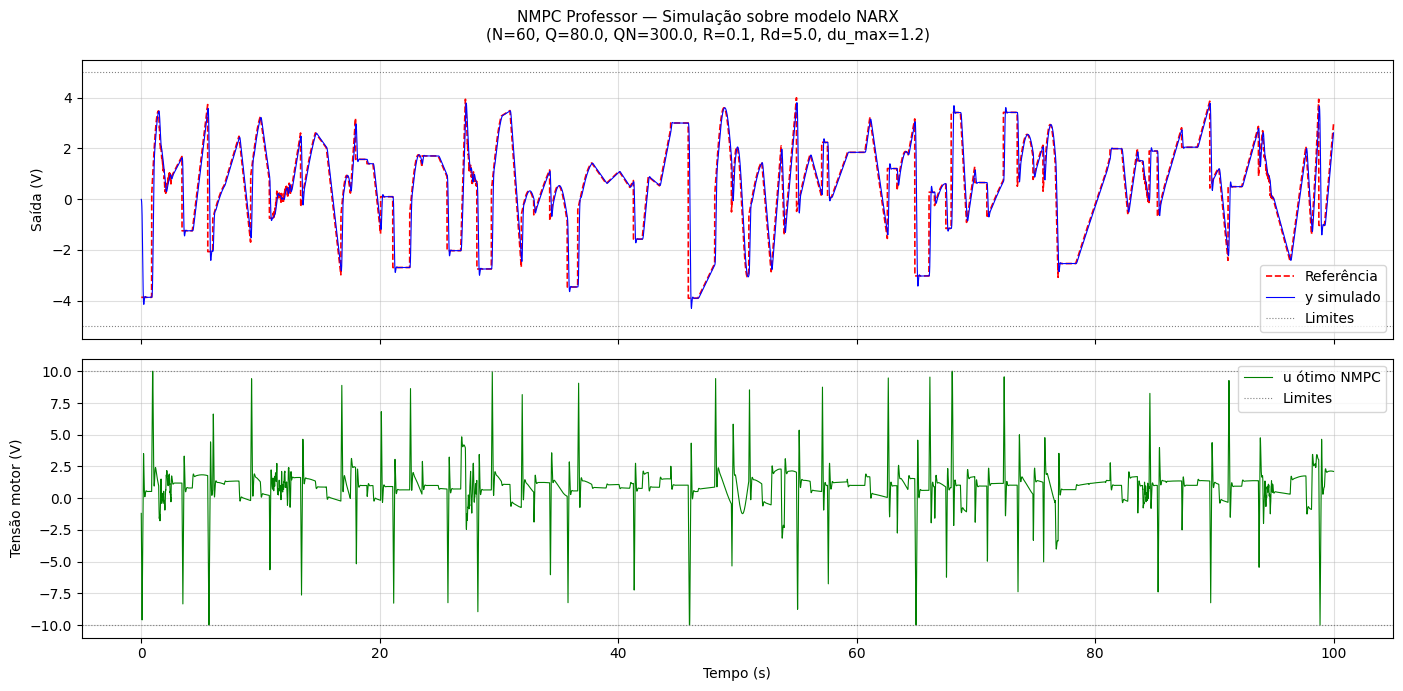


=== Métricas: NMPC Professor ===
  RMSE        : 0.6871
  MAE         : 0.2804
  FIT_%       : 60.7310
  R2          : 0.8458
  Sat_%       : 0.1600
  du_RMS      : 0.3325
  du_max_abs  : 1.2000


In [ ]:
# =============================================================================
# CÉLULA 4E — VISUALIZAÇÃO E MÉTRICAS DO NMPC PROFESSOR
# =============================================================================

def compute_metrics(ref, y, u, label=''):
    erro = ref - y; du = np.diff(u)
    metrics = {
        'RMSE':       float(np.sqrt(np.mean(erro**2))),
        'MAE':        float(np.mean(np.abs(erro))),
        'FIT_%':      float(100*(1 - np.linalg.norm(erro) /
                           (np.linalg.norm(ref-np.mean(ref))+1e-12))),
        'R2':         float(1 - np.sum(erro**2) / (np.sum((ref-np.mean(ref))**2)+1e-12)),
        'Sat_%':      float(100*np.mean(np.abs(u) >= 0.98*config['u_max'])),
        'du_RMS':     float(np.sqrt(np.mean(du**2))) if len(du) else 0.,
        'du_max_abs': float(np.max(np.abs(du)))      if len(du) else 0.,
    }
    if label:
        print(f'\n=== Métricas: {label} ===')
        for k, v in metrics.items(): print(f'  {k:12s}: {v:.4f}')
    return metrics


if CASADI_OK and 'hist_y' in dir():
    t_ds = np.arange(len(hist_y)) * Ts
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle('NMPC Professor — Simulação sobre modelo NARX\n'
                 f'(N={N}, Q={Q}, QN={QN}, R={R}, Rd={Rd}, du_max={du_max})', fontsize=11)
    axes[0].plot(t_ds, hist_ref, 'r--', lw=1.2, label='Referência')
    axes[0].plot(t_ds, hist_y,   'b-',  lw=0.8, label='y simulado')
    axes[0].axhline(config['y_min'], color='gray', ls=':', lw=0.8, label='Limites')
    axes[0].axhline(config['y_max'], color='gray', ls=':', lw=0.8)
    axes[0].set_ylabel('Saída (V)'); axes[0].grid(True, alpha=0.4); axes[0].legend()
    axes[1].plot(t_ds, hist_u, 'g-', lw=0.8, label='u ótimo NMPC')
    axes[1].axhline(config['u_min'], color='gray', ls=':', lw=0.8, label='Limites')
    axes[1].axhline(config['u_max'], color='gray', ls=':', lw=0.8)
    axes[1].set_xlabel('Tempo (s)'); axes[1].set_ylabel('Tensão motor (V)')
    axes[1].grid(True, alpha=0.4); axes[1].legend()
    plt.tight_layout(); plt.show()
    metrics_nmpc = compute_metrics(hist_ref, hist_y, hist_u, label='NMPC Professor')


## Seção 5 — Persistência do Dataset e do NMPC

In [ ]:
# =============================================================================
# CÉLULA 5A — SALVAR DATASET E PARÂMETROS NMPC NO DRIVE
# =============================================================================

SALVAR_DATASET = True

if SALVAR_DATASET and 'df_dataset' in dir():
    save_dir = Path(PATH_SAVE)
    save_dir.mkdir(parents=True, exist_ok=True)

    # Dataset CSV
    csv_path = save_dir / 'dataset_nmpc_final1.csv'
    df_dataset.to_csv(str(csv_path), index=False)

    # Parâmetros NMPC em JSON
    nmpc_params = {'N': N, 'Q': Q, 'QN': QN, 'R': R, 'Rd': Rd,
                   'du_max': du_max, 'Ts': Ts,
                   'u_min': config['u_min'], 'u_max': config['u_max'],
                   'y_min': config['y_min'], 'y_max': config['y_max'],
                   'nx': nx, 'columns_state': columns_state}
    with open(save_dir / 'nmpc_params_final1.json', 'w') as f:
        json.dump(nmpc_params, f, indent=2)

    print(f'✓ Dataset salvo em: {csv_path}  ({len(df_dataset)} amostras)')
    print(f'✓ Parâmetros NMPC salvos em: {save_dir / "nmpc_params_final1.json"}')
else:
    print('Salvamento desativado ou dataset não gerado.')


✓ Dataset salvo em: /content/drive/MyDrive/bab_dados_mat/dataset_nmpc_final1.csv  (10000 amostras)
✓ Parâmetros NMPC salvos em: /content/drive/MyDrive/bab_dados_mat/nmpc_params_final1.json


In [ ]:
# =============================================================================
# CÉLULA 5B — CARREGAR DATASET DO DRIVE (nova sessão)
# =============================================================================

CARREGAR_DATASET = True   # mude para True ao recarregar

if CARREGAR_DATASET:
    csv_path = Path(PATH_SAVE) / 'dataset_nmpc_final1.csv'
    df_dataset = pd.read_csv(str(csv_path))

    # Restaura variáveis necessárias para as próximas seções
    nx = model['ny'] + model['nu']
    columns_state = [f'x{i}' for i in range(nx)]

    # Carrega parâmetros NMPC
    params_path = Path(PATH_SAVE) / 'nmpc_params_final1.json'
    if params_path.exists():
        with open(str(params_path)) as f:
            p = json.load(f)
        N, Q, QN, R, Rd, du_max = p['N'], p['Q'], p['QN'], p['R'], p['Rd'], p['du_max']
        print(f'Parâmetros NMPC carregados: N={N} Q={Q} QN={QN} R={R} Rd={Rd} du_max={du_max}')

    print(f'✓ Dataset carregado: {len(df_dataset)} amostras')
    print(df_dataset.describe().round(4))
else:
    print('Carregamento desativado (CARREGAR_DATASET = False).')


Parâmetros NMPC carregados: N=60 Q=80.0 QN=300.0 R=0.1 Rd=5.0 du_max=1.2
✓ Dataset carregado: 10000 amostras
               x0          x1          x2          x3          x4         ref  \
count  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000   
mean       0.5424      0.5421      0.9161      0.9159      0.9157      0.5278   
std        1.7358      1.7356      1.5553      1.5553      1.5553      1.7498   
min       -4.3022     -4.3022    -10.0000    -10.0000    -10.0000     -3.9032   
25%       -0.2956     -0.2956      0.6085      0.6082      0.6077     -0.3163   
50%        0.7713      0.7706      1.0110      1.0110      1.0110      0.7541   
75%        1.7526      1.7516      1.3737      1.3736      1.3735      1.7437   
max        3.8057      3.8057     10.0000     10.0000     10.0000      3.9960   

        u_optimal      y_next  solver_ok  
count  10000.0000  10000.0000    10000.0  
mean       0.9163      0.5426        1.0  
std        1.5553      1.7359   

## Seção 6 — MPC Aproximado

Amostras para treino: 10000 (100.0% do dataset)
Treinando MPC Aproximado...

=== Qualidade da imitação ===
  Treino    — RMSE: 0.0582 V  R²: 0.9986
  Validação — RMSE: 0.0627 V  R²: 0.9985
  ✓ Qualidade adequada.


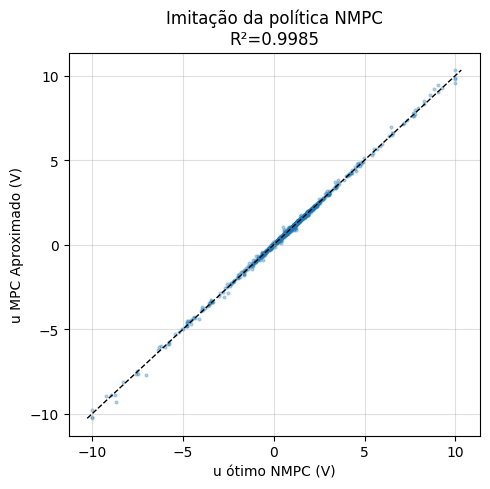

In [ ]:
# =============================================================================
# CÉLULA 6A — TREINAMENTO DO MPC APROXIMADO
# =============================================================================
# Treina uma rede MLP para aprender a política do NMPC Professor:
#
#   π_θ([x(k), r(k)]) ≈ u*(k)
#
# Arquitetura: MLP com 3 camadas ocultas (128–64–32), ativação tanh, Adam.
# A normalização (StandardScaler) é aplicada antes da rede.
#
# Vantagem do MPC Aproximado:
#   - Tempo de inferência: microssegundos (vs segundos do NMPC)
#   - Adequado para implementação embarcada
#   - Preserva as restrições aprendidas implicitamente
#
# Critério de qualidade:
#   R² ≥ 0.90 na imitação indica que a rede capturou bem a política.
# =============================================================================

if 'df_dataset' in dir():
    df_ok = df_dataset[df_dataset['solver_ok'] == 1].copy()
    print(f'Amostras para treino: {len(df_ok)} ({100*len(df_ok)/len(df_dataset):.1f}% do dataset)')

    if len(df_ok) < 500: #corrigir para 5000
        print('⚠ Poucas amostras. Recomendado: num_steps_dataset ≥ 20000.')

    X_mpc = df_ok[columns_state + ['ref']].values
    y_mpc = df_ok['u_optimal'].values

    X_tr, X_vl, y_tr, y_vl = train_test_split(
        X_mpc, y_mpc, test_size=0.20, random_state=42, shuffle=True)

    approx_mpc = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=(128, 64, 32), activation='tanh',
            solver='adam', alpha=1e-5, learning_rate_init=1e-3,
            max_iter=3000, random_state=42,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=50, verbose=False
        ))
    ])

    print('Treinando MPC Aproximado...')
    approx_mpc.fit(X_tr, y_tr)

    yhat_tr = approx_mpc.predict(X_tr)
    yhat_vl = approx_mpc.predict(X_vl)
    print(f'\n=== Qualidade da imitação ===')
    print(f'  Treino    — RMSE: {np.sqrt(mean_squared_error(y_tr, yhat_tr)):.4f} V  '
          f'R²: {r2_score(y_tr, yhat_tr):.4f}')
    print(f'  Validação — RMSE: {np.sqrt(mean_squared_error(y_vl, yhat_vl)):.4f} V  '
          f'R²: {r2_score(y_vl, yhat_vl):.4f}')

    if r2_score(y_vl, yhat_vl) < 0.90:
        print('  ⚠ R² < 0.90: aumente num_steps_dataset ou revise a diversidade do dataset.')
    else:
        print('  ✓ Qualidade adequada.')

    # Gráfico u ótimo × u aproximado
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_vl, yhat_vl, s=4, alpha=0.3, c='C0')
    lims = [min(y_vl.min(), yhat_vl.min()), max(y_vl.max(), yhat_vl.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel('u ótimo NMPC (V)'); ax.set_ylabel('u MPC Aproximado (V)')
    ax.set_title(f'Imitação da política NMPC\nR²={r2_score(y_vl,yhat_vl):.4f}')
    ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()
else:
    print('Execute a Célula 4D (geração do dataset) antes.')


In [ ]:
# =============================================================================
# CÉLULA 6B — SALVAR MPC APROXIMADO NO DRIVE
# =============================================================================

SALVAR_MPC_APROX = True

if SALVAR_MPC_APROX and 'approx_mpc' in dir():
    save_dir = Path(PATH_SAVE)
    save_dir.mkdir(parents=True, exist_ok=True)

    # .pkl — modelo completo
    pkl_path = save_dir / 'approx_mpc_final1.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(approx_mpc, f)

    # .npz — pesos e bias para exportação (ex: C/C++ embarcado)
    mlp = approx_mpc.named_steps['mlp']
    scl = approx_mpc.named_steps['scaler']
    npz_path = save_dir / 'approx_mpc_weights_final1.npz'
    np.savez(str(npz_path),
             scaler_mean=scl.mean_, scaler_scale=scl.scale_,
             **{f'W{i}': w for i, w in enumerate(mlp.coefs_)},
             **{f'b{i}': b for i, b in enumerate(mlp.intercepts_)})

    print(f'✓ MPC Aproximado salvo em:')
    print(f'  {pkl_path}  (modelo completo)')
    print(f'  {npz_path}  (pesos e bias)')
else:
    print('Salvamento desativado ou approx_mpc não treinado.')


✓ MPC Aproximado salvo em:
  /content/drive/MyDrive/bab_dados_mat/approx_mpc_final1.pkl  (modelo completo)
  /content/drive/MyDrive/bab_dados_mat/approx_mpc_weights_final1.npz  (pesos e bias)


In [ ]:
# =============================================================================
# CÉLULA 6C — CARREGAR MPC APROXIMADO DO DRIVE (nova sessão)
# =============================================================================

CARREGAR_MPC_APROX = True   # mude para True ao recarregar

if CARREGAR_MPC_APROX:
    pkl_path = Path(PATH_SAVE) / 'approx_mpc_final1.pkl'
    with open(str(pkl_path), 'rb') as f:
        approx_mpc = pickle.load(f)
    print(f'✓ MPC Aproximado carregado de: {pkl_path}')
    print(f'  Arquitetura MLP: {approx_mpc.named_steps["mlp"].hidden_layer_sizes}')
else:
    print('Carregamento desativado (CARREGAR_MPC_APROX = False).')


✓ MPC Aproximado carregado de: /content/drive/MyDrive/bab_dados_mat/approx_mpc_final1.pkl
  Arquitetura MLP: (128, 64, 32)


## Seção 7 — Comparação e Avaliação Final

✓ Solver NMPC funcional. Teste: u=1.2000


MPC Aproximado:   0%|          | 0/6000 [00:00<?, ?it/s]

NMPC Professor:   0%|          | 0/6000 [00:00<?, ?it/s]

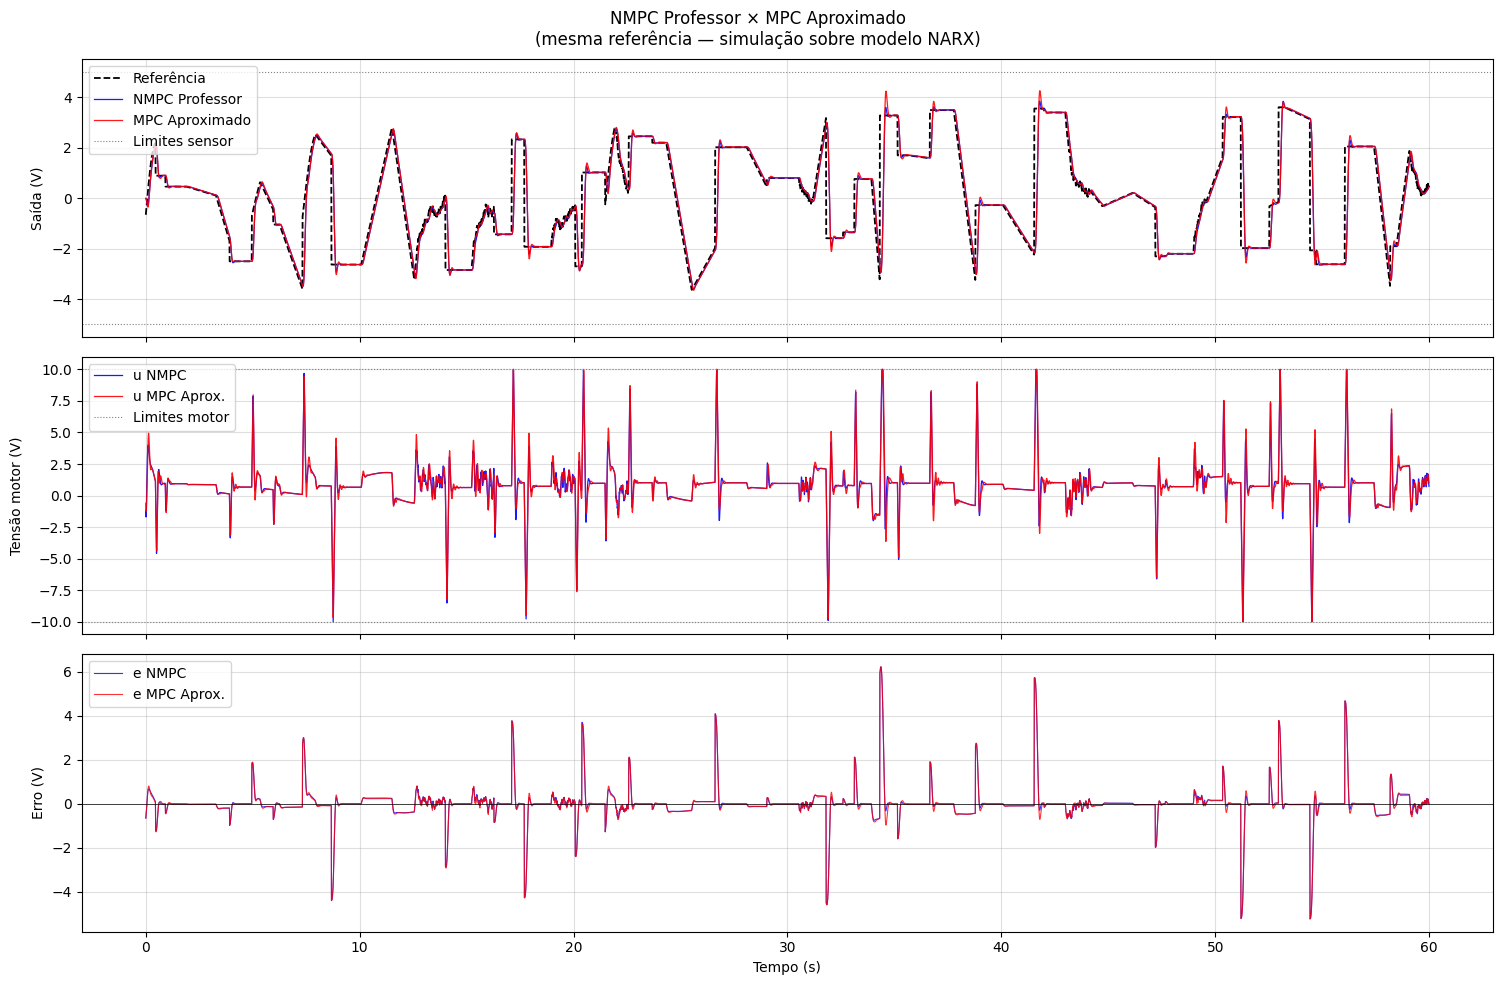


=== Métricas: NMPC Professor ===
  RMSE        : 0.7792
  MAE         : 0.2781
  FIT_%       : 59.2224
  R2          : 0.8337
  Sat_%       : 0.4333
  du_RMS      : 0.3477
  du_max_abs  : 1.2000

=== Métricas: MPC Aproximado ===
  RMSE        : 0.7904
  MAE         : 0.2917
  FIT_%       : 58.6362
  R2          : 0.8289
  Sat_%       : 0.3333
  du_RMS      : 0.3452
  du_max_abs  : 1.2000


In [ ]:
# =============================================================================
# CÉLULA 7A — SIMULAÇÃO COMPARATIVA: NMPC × MPC APROXIMADO
# =============================================================================
# Ambos os controladores são simulados sobre a mesma referência (seed=999)
# para garantir que a comparação seja justa.
#
# Correção aplicada no MPC Aproximado:
#   u_aprox é clipado em [u_prev ± du_max] antes de ser aplicado,
#   mantendo consistência com a restrição du_max do professor NMPC.
# =============================================================================

# Verifica se o solver está disponível e funcional
try:
    u_teste, _ = solve_nmpc_one_step(np.zeros(nx), 0.5, 0., np.zeros(N))
    print(f'✓ Solver NMPC funcional. Teste: u={u_teste:.4f}')
except Exception as e:
    print(f'✗ Solver NMPC inválido: {e}')
    print('  Reexecute a Célula 4B antes de continuar.')

if CASADI_OK and 'approx_mpc' in dir():
    SEED_COMPARE  = 999
    num_steps_sim = 6000
    ref_compare   = generate_reference_profile(num_steps_sim, Ts, seed=SEED_COMPARE)

    # ── MPC Aproximado ────────────────────────────────────────────────────────
    x_ap, u_ap_prev = np.zeros(nx), 0.
    y_hist_ap, u_hist_ap = [], []
    for k in tqdm(range(num_steps_sim), desc='MPC Aproximado'):
        u_raw = float(approx_mpc.predict(
            np.r_[x_ap, ref_compare[k]].reshape(1,-1))[0])
        u_ap  = np.clip(u_raw, u_ap_prev - du_max, u_ap_prev + du_max)
        u_ap  = np.clip(u_ap, config['u_min'], config['u_max'])
        x_ap  = state_transition_numpy(x_ap, u_ap, model)
        x_ap[0] = np.clip(x_ap[0], config['y_min'], config['y_max'])
        y_hist_ap.append(x_ap[0]); u_hist_ap.append(u_ap); u_ap_prev = u_ap
    y_hist_ap = np.asarray(y_hist_ap); u_hist_ap = np.asarray(u_hist_ap)

    # ── NMPC Professor (mesma referência) ─────────────────────────────────────
    x_nm, u_nm_prev, u_nm_guess = np.zeros(nx), 0., np.zeros(N)
    y_hist_nm, u_hist_nm = [], []
    for k in tqdm(range(num_steps_sim), desc='NMPC Professor'):
        try:
            u_nm, Uopt = solve_nmpc_one_step(x_nm, ref_compare[k], u_nm_prev, u_nm_guess)
            u_nm_guess = np.r_[Uopt[1:], Uopt[-1]]
        except Exception: u_nm = u_nm_prev
        x_nm = state_transition_numpy(x_nm, u_nm, model)
        x_nm[0] = np.clip(x_nm[0], config['y_min'], config['y_max'])
        y_hist_nm.append(x_nm[0]); u_hist_nm.append(u_nm); u_nm_prev = u_nm
    y_hist_nm = np.asarray(y_hist_nm); u_hist_nm = np.asarray(u_hist_nm)
    t_cmp = np.arange(num_steps_sim) * Ts

    # ── Gráfico comparativo ───────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig.suptitle('NMPC Professor × MPC Aproximado\n'
                 '(mesma referência — simulação sobre modelo NARX)', fontsize=12)

    axes[0].plot(t_cmp, ref_compare, 'k--', lw=1.3, label='Referência')
    axes[0].plot(t_cmp, y_hist_nm,   'b-',  lw=0.9, label='NMPC Professor', alpha=0.9)
    axes[0].plot(t_cmp, y_hist_ap,   'r-',  lw=0.9, label='MPC Aproximado', alpha=0.9)
    axes[0].axhline(config['y_min'], color='gray', ls=':', lw=0.8, label='Limites sensor')
    axes[0].axhline(config['y_max'], color='gray', ls=':', lw=0.8)
    axes[0].set_ylabel('Saída (V)'); axes[0].grid(True, alpha=0.4); axes[0].legend()

    axes[1].plot(t_cmp, u_hist_nm, 'b-', lw=0.9, label='u NMPC',       alpha=0.9)
    axes[1].plot(t_cmp, u_hist_ap, 'r-', lw=0.9, label='u MPC Aprox.', alpha=0.9)
    axes[1].axhline(config['u_min'], color='gray', ls=':', lw=0.8, label='Limites motor')
    axes[1].axhline(config['u_max'], color='gray', ls=':', lw=0.8)
    axes[1].set_ylabel('Tensão motor (V)'); axes[1].grid(True, alpha=0.4); axes[1].legend()

    # Erro de rastreamento
    axes[2].plot(t_cmp, ref_compare - y_hist_nm, 'b-', lw=0.8, label='e NMPC',       alpha=0.8)
    axes[2].plot(t_cmp, ref_compare - y_hist_ap, 'r-', lw=0.8, label='e MPC Aprox.', alpha=0.8)
    axes[2].axhline(0, color='k', ls='-', lw=0.5)
    axes[2].set_xlabel('Tempo (s)'); axes[2].set_ylabel('Erro (V)')
    axes[2].grid(True, alpha=0.4); axes[2].legend()

    plt.tight_layout(); plt.show()

    metrics_nm = compute_metrics(ref_compare, y_hist_nm, u_hist_nm, label='NMPC Professor')
    metrics_ap = compute_metrics(ref_compare, y_hist_ap, u_hist_ap, label='MPC Aproximado')
else:
    print('Execute as células 4B e 6A antes.')


In [ ]:
# =============================================================================
# CÉLULA 7B — PAINEL UNIFICADO DE MÉTRICAS
# =============================================================================
# Tabela comparativa final com interpretação de cada métrica.
#
# Interpretação:
#   RMSE / MAE  : erro médio de rastreamento (menor = melhor)
#   FIT_%       : índice NRMSE (maior = melhor; 100% = perfeito)
#   R²          : coeficiente de determinação (próximo de 1 = melhor)
#   Sat_%       : % do tempo em saturação do atuador (idealmente < 5%)
#   du_RMS      : variação RMS do controle (menor = mais suave)
#   du_max_abs  : máxima variação observada (deve ser ≤ du_max)
#
# Δ rel. positivo significa que o MPC Aproximado é PIOR que o professor
# (exceto FIT_% e R², onde positivo = melhor).
# =============================================================================

if 'metrics_nm' in dir() and 'metrics_ap' in dir():
    delta = []
    for nm, ap in zip(metrics_nm.values(), metrics_ap.values()):
        delta.append(f'{100*(ap-nm)/abs(nm):+.1f}%' if abs(nm) > 1e-12 else '—')

    df_panel = pd.DataFrame({
        'Métrica':             list(metrics_nm.keys()),
        'NMPC Professor':      [f'{v:.4f}' for v in metrics_nm.values()],
        'MPC Aproximado':      [f'{v:.4f}' for v in metrics_ap.values()],
        'Δ rel. (Aprox−Prof)': delta,
    })

    print('\n' + '='*72)
    print('  PAINEL COMPARATIVO — Simulação sobre modelo NARX')
    print('='*72)
    print(df_panel.to_string(index=False))
    print('='*72)

    # Análise automática
    rmse_ratio = metrics_ap['RMSE'] / (metrics_nm['RMSE'] + 1e-12)
    print(f'\nAnálise automática:')
    print(f'  Razão RMSE (Aprox/Prof): {rmse_ratio:.2f}x')
    if rmse_ratio < 1.5:
        print('  ✓ MPC Aproximado com desempenho próximo ao professor (< 1.5×).')
    elif rmse_ratio < 2.0:
        print('  ⚠ Degradação moderada (1.5–2×). Aumente num_steps_dataset.')
    else:
        print('  ✗ Degradação significativa (> 2×). Revise dataset e arquitetura da rede.')

    print(f'\n  Nota: resultados válidos APENAS em simulação sobre o modelo NARX.')
    print(f'  Validação na planta física é etapa futura.')
else:
    print('Execute a Célula 7A antes.')



  PAINEL COMPARATIVO — Simulação sobre modelo NARX
   Métrica NMPC Professor MPC Aproximado Δ rel. (Aprox−Prof)
      RMSE         0.7792         0.7904               +1.4%
       MAE         0.2781         0.2917               +4.9%
     FIT_%        59.2224        58.6362               -1.0%
        R2         0.8337         0.8289               -0.6%
     Sat_%         0.4333         0.3333              -23.1%
    du_RMS         0.3477         0.3452               -0.7%
du_max_abs         1.2000         1.2000               -0.0%

Análise automática:
  Razão RMSE (Aprox/Prof): 1.01x
  ✓ MPC Aproximado com desempenho próximo ao professor (< 1.5×).

  Nota: resultados válidos APENAS em simulação sobre o modelo NARX.
  Validação na planta física é etapa futura.


In [ ]:
# ============================================================
# COMPARAÇÃO DAS AÇÕES DE CONTROLE
# ============================================================

rmse_u = np.sqrt(np.mean((u_hist_nm - u_hist_ap)**2))
mae_u  = np.mean(np.abs(u_hist_nm - u_hist_ap))

print('\n' + '='*72)
print('  COMPARAÇÃO DAS AÇÕES DE CONTROLE (u)')
print('='*72)
print(f'  RMSE_u : {rmse_u:.4f} V')
print(f'  MAE_u  : {mae_u:.4f} V')

# Correlação
corr_u = np.corrcoef(u_hist_nm, u_hist_ap)[0,1]
print(f'  Correlação u: {corr_u:.4f}')

# Análise simples
if rmse_u < 0.2:
    print('  ✓ Excelente imitação da política de controle')
elif rmse_u < 0.5:
    print('  ⚠ Boa imitação, com pequenas diferenças')
else:
    print('  ✗ Diferença significativa na política de controle')


  COMPARAÇÃO DAS AÇÕES DE CONTROLE (u)
  RMSE_u : 0.3147 V
  MAE_u  : 0.1519 V
  Correlação u: 0.9820
  ⚠ Boa imitação, com pequenas diferenças


---

## Guia de uso

### Ordem de execução (primeira vez)

| Seção | Células | Ação |
|---|---|---|
| 0 | 0A → 0C | Instalar, importar, configurar |
| 1 | 1A | Carregar e inspecionar dados |
| 2 | 2A → 2G | Identificar NARX, grid search, SEM |
| 3 | 3A | Salvar modelo NARX no Drive |
| 4 | 4A → 4E | Construir NMPC, gerar dataset |
| 5 | 5A | Salvar dataset e parâmetros NMPC |
| 6 | 6A → 6B | Treinar e salvar MPC Aproximado |
| 7 | 7A → 7B | Comparar e avaliar |

### Retomar após sessão encerrada

1. Rerrodar células **0B, 0C, 1A, 2A, 2B** (funções — rápido)
2. Ativar `CARREGAR_NARX = True` → Célula 3B
3. Ativar `CARREGAR_DATASET = True` → Célula 5B
4. Ativar `CARREGAR_MPC_APROX = True` → Célula 6C
5. Rerrodar **4A, 4B, 4C** (funções)
6. Continuar da Célula 7A

> **Escopo:** todos os resultados são de simulação sobre o modelo NARX identificado.  
> A validação na planta física é etapa futura e pode exigir re-identificação com dados em malha fechada.
